## **Statistical properties of dominant flow modes** *[borrowed from Dynamique des structures cohérentes en turbulence magnétohydrodynamique by Johann Herault]*

### Cadre théorique et position du problème

L’étude des processus aléatoires constitués de séries d’évènements aléatoires se
nomme théorie du renouvellement. Dans notre problème, les événements correspondent
à des transitions entre $\chi = \pm1$, espacés par des durées $τ$ indépendamment distribuées
selon la loi $P(\tau)$. À chaque réalisation de ce processus comportant $N$ évènements,
est associée la série $(\tau_1 , \tau_2 , \cdots , \tau_N )$. Soit $u(t)$, une réalisation de ce
processus valant $\chi_k = \pm1$ pendant la k-ième polarité telle que

\begin{equation}
u(t) = \chi_k, \mbox{ avec } t \in [T_k, T_{k+1}]
\end{equation}
et $\chi_{k+1}=-\chi_k$. 

Nous souhaitons donc calculer le spectre $E(f)$ de $u(t)$.

### Calcul du spectre par arguments qualitatifs

Nous présentons ici un calcul du spectre à partir d’arguments qualitatifs. Une dé-
monstration plus complète est présentée dans l’article de Niemann et al. Notre
démonstration vise à montrer que la fonction d’auto-corrélation temporelle $C(t)$ de
$u(t)$ admet une décroissance en loi de puissance, due à la présence d’évènements longs.
Puis nous calculerons le spectre à partir de la fonction de corrélation grâce au théorème
de Wiener-Khintchine

\begin{equation}
E(f) = \int C(t) \exp{(i \omega t)} dt
\end{equation}
avec $C(t)$ la fonction d’auto-corrélation temporelle du signal $u(t)$ définie par
\begin{equation}
C(t) = \frac{1}{T}\int u(t'+t) u(t') dt' = \frac{1}{\langle \tau \rangle}\int (\tau - t) P(\tau) d\tau
\end{equation}

- Case for Exponential distribution $P(\tau) = \lambda\exp{(\lambda t)}$

\begin{equation}
C(t) = \frac{1}{\langle \tau \rangle}\int_t^\infty (\tau - t) \lambda\exp{(\lambda \tau)} d\tau
\end{equation}

## Preamble

In [25]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_rows',10)

params = {'backend': 'ps',
          'axes.labelsize': 16,
          'font.size': 16,
          'legend.fontsize': 16,          
          'font.size': 16,          
          'xtick.labelsize': 12,
          'ytick.labelsize': 12,
          'text.usetex': True,
          'font.family': 'serif',
          'figure.figsize': (12, 8),
          'contour.negative_linestyle':'dashed'}
plt.rcParams.update(params)

### 1. Read the time series

In [26]:
filename_modes_pr3   = './data_from_dns/modal_50000000_3_512_016to186.h5'
filename_global_pr3  = './data_from_dns/global_50000000_3_512_016to186.h5'
filename_nusselt_pr3 = './data_from_dns/nusselt_50000000_3_512_016to186.h5'

filename_modes_pr43   = './data_from_dns/modal_50000000_4.3_512_060to259.h5'
filename_global_pr43  = './data_from_dns/global_50000000_4.3_512_060to259.h5'
filename_nusselt_pr43 = './data_from_dns/nusselt_50000000_4.3_512_060to259.h5'

In [27]:
glb_pr3 = pd.read_hdf(filename_global_pr3)
nus_pr3 = pd.read_hdf(filename_nusselt_pr3)
pod_pr3 = pd.read_hdf(filename_modes_pr3)

n=glb_pr3.shape[0]
t = np.arange(n)/20.
glb_pr3['t'] = t
nus_pr3['t'] = t
pod_pr3['t'] = t

### 2. Power spectral densities (PSD) of the POD modes (complete series)

In [28]:
from scipy import signal
nperseg=1024*16
fsampling=0.05
welch_pod_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
psd_pod_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])

welchs_pod_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
psds_pod_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])

welcha_pod_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
psda_pod_pr3 = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])


n = pod_pr3['k1'].values.size
m = int(n/2)
psd_pod_pr3['f']= np.fft.fftfreq(n, fsampling)[0:m]
psda_pod_pr3['f']= np.fft.fftfreq(n, fsampling)[0:m]
psds_pod_pr3['f']= np.fft.fftfreq(n, fsampling)[0:m]
for k in ['k1', 'k2', 'k3', 'k4', 'k5', 'k6']:    
    psd_pod_pr3[k] = np.abs(np.fft.fft(pod_pr3[k].values)[0:m])**2./n    
    welch_pod_pr3.f, welch_pod_pr3[k] = signal.welch(pod_pr3[k].values, 1./fsampling, nperseg=nperseg, scaling='density')
    
    psda_pod_pr3[k] = np.abs(np.fft.fft(np.abs(pod_pr3[k].values))[0:m])**2./n
    welcha_pod_pr3.f, welcha_pod_pr3[k] = signal.welch(np.abs(pod_pr3[k].values), 1./fsampling, nperseg=nperseg, scaling='density')
    
    psds_pod_pr3[k] = np.abs(np.fft.fft(np.sign(pod_pr3[k].values))[0:m])**2./n
    welchs_pod_pr3.f, welchs_pod_pr3[k] = signal.welch(np.sign(pod_pr3[k].values), 1./fsampling, nperseg=nperseg, scaling='density')

/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in power
  if __name__ == '__main__':
/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in power
  # Remove the CWD from sys.path while we load stuff.


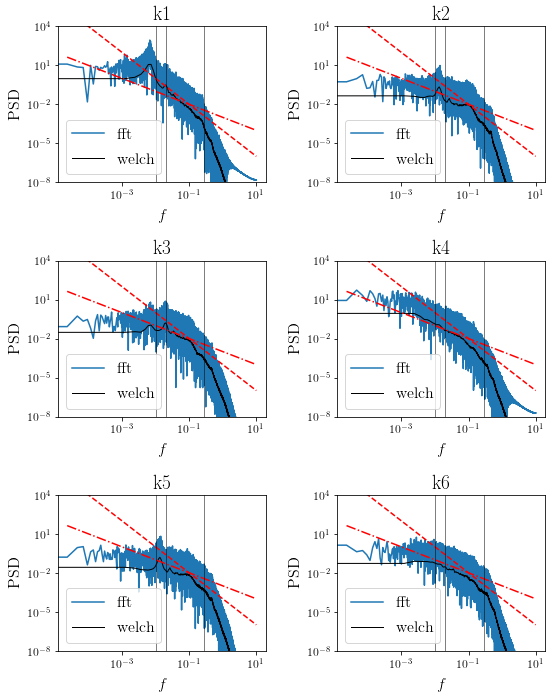

In [29]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    psd_pod_pr3.plot(x='f', y=k, logx=True, logy=True, ax=ax[i])    
    welch_pod_pr3.plot(x='f', y=k, logx=True, logy=True, ax=ax[i], color='k', linewidth=1.0)
    
    ax[i].plot(psd_pod_pr3.f, 1e-3*np.power(psd_pod_pr3.f,-1), 'r', linestyle='-.')
    ax[i].plot(psd_pod_pr3.f, 1e-4*np.power(psd_pod_pr3.f,-2), 'r', linestyle='--')
    #ax[i].plot(psd_pod_pr3.f, 1e-4*np.power(psd_pod_pr3.f,-8), 'r', linestyle='-.')
    ax[i].legend(['fft','welch'])
    ax[i].set_ylim([1e-8,1e4])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD')
    ax[i].set_title(k)
    
    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)

plt.tight_layout()

/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in power
  if __name__ == '__main__':


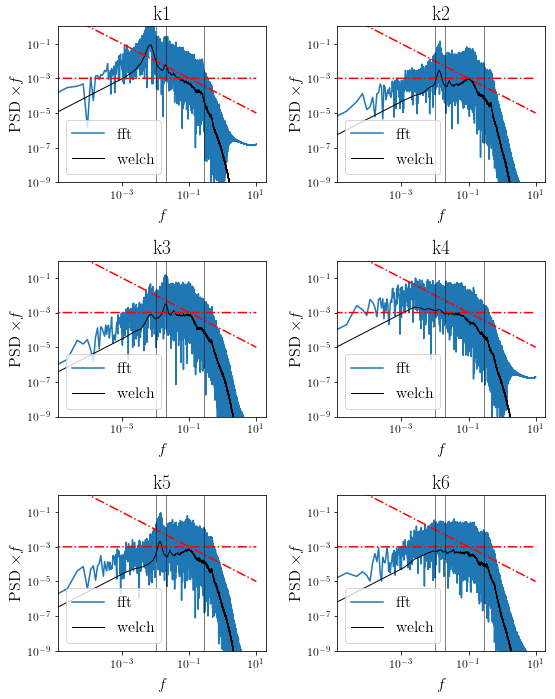

In [30]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    ax[i].loglog(psd_pod_pr3['f'],   psd_pod_pr3[k]*np.power(psd_pod_pr3['f'],1.0))
    ax[i].loglog(welch_pod_pr3['f'], welch_pod_pr3[k]*np.power(welch_pod_pr3['f'],1.0), color='k', linewidth=1.0)
    
    ax[i].loglog(psd_pod_pr3['f'],   1e-4*np.power(psd_pod_pr3['f'],-1), 'r', linestyle='-.')
    ax[i].loglog(psd_pod_pr3['f'],   1e-3*np.power(psd_pod_pr3['f'],0), 'r', linestyle='-.')
    ax[i].legend(['fft','welch'])
    ax[i].set_ylim([1e-9,1e-0])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD $\\times f $')
    ax[i].set_title(k)
    
    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)
    
plt.tight_layout()

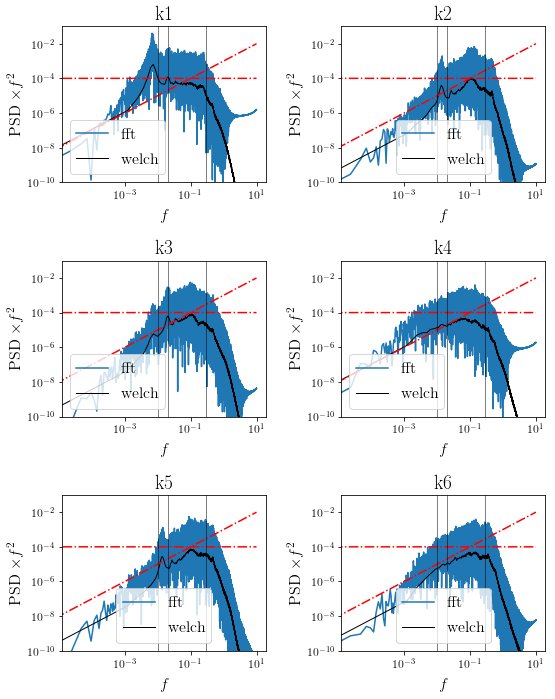

In [31]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    ax[i].loglog(psd_pod_pr3['f'],   psd_pod_pr3[k]*np.power(psd_pod_pr3['f'],2.0))
    ax[i].loglog(welch_pod_pr3['f'], welch_pod_pr3[k]*np.power(welch_pod_pr3['f'],2.0), color='k', linewidth=1.0)
    
    ax[i].loglog(psd_pod_pr3['f'],   1e-4*np.power(psd_pod_pr3['f'],0), 'r', linestyle='-.')
    ax[i].loglog(psd_pod_pr3['f'],   1e-3*np.power(psd_pod_pr3['f'],1), 'r', linestyle='-.')
    
    ax[i].legend(['fft','welch'])
    ax[i].set_ylim([1e-10,1e-1])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD $\\times f^2 $')
    ax[i].set_title(k)
    
    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)
    
plt.tight_layout()

/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in power
  from ipykernel import kernelapp as app
/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:16: RuntimeWarning: divide by zero encountered in power
  app.launch_new_instance()


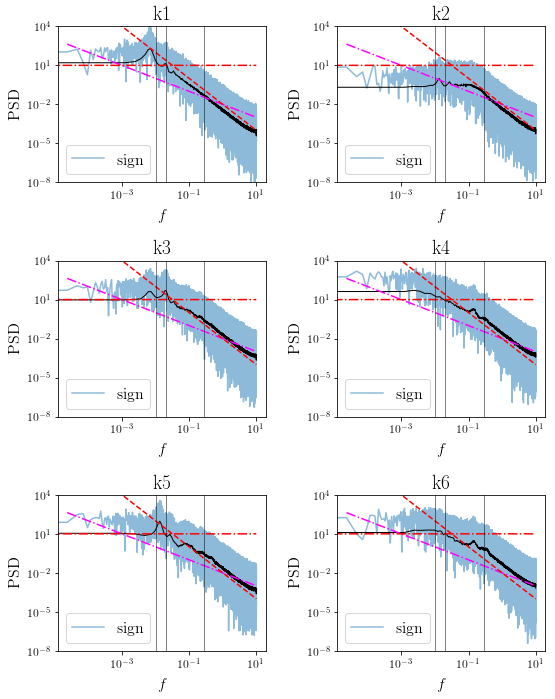

In [32]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    psds_pod_pr3.plot(x='f', y=k, logx=True, logy=True, ax=ax[i], alpha=0.5)
    #psd_pod_pr3.plot(x='f', y=k, logx=True, logy=True, ax=ax[i], alpha=0.5)    
    #psda_pod_pr3.plot(x='f', y=k, logx=True, logy=True, ax=ax[i], alpha=0.5)
    
    
    welchs_pod_pr3.plot(x='f', y=k, logx=True, logy=True, ax=ax[i], color='k', linewidth=1.0)
    #welch_pod_pr3.plot(x='f', y=k, logx=True, logy=True, ax=ax[i], color='cyan', linewidth=1.0)
    #welcha_pod_pr3.plot(x='f', y=k, logx=True, logy=True, ax=ax[i], color='k', linewidth=1.0)
    
    ax[i].plot(psd_pod_pr3.f, 1e-2*np.power(psd_pod_pr3.f,-1), 'magenta', linestyle='-.')
    ax[i].plot(psd_pod_pr3.f, 1e-2*np.power(psd_pod_pr3.f,-2), 'r', linestyle='--')
    ax[i].plot(psd_pod_pr3.f, 1e1*np.power(psd_pod_pr3.f,-0), 'r', linestyle='-.')
    ax[i].legend(['sign'])
    ax[i].set_ylim([1e-8,1e4])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD')
    ax[i].set_title(k)
    
    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)


plt.tight_layout()

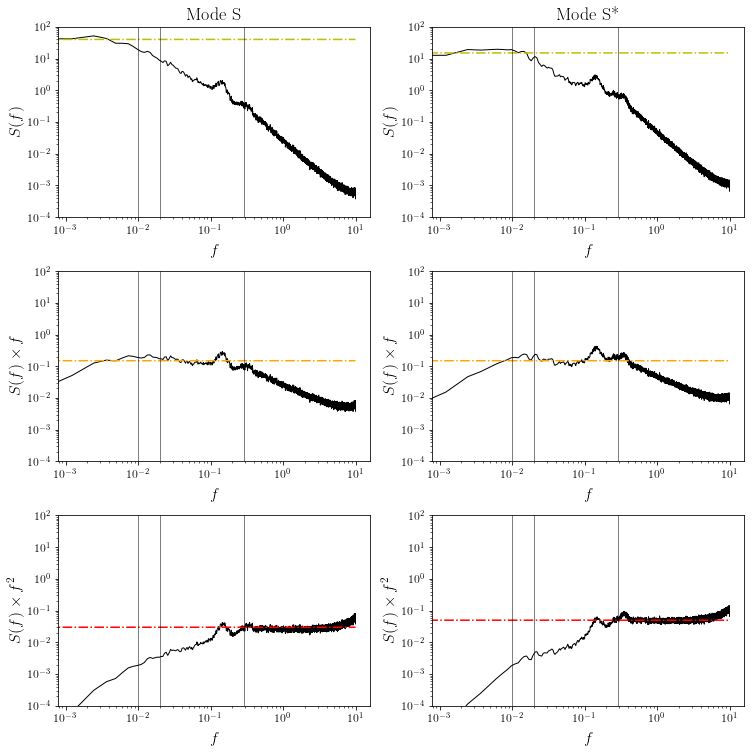

In [33]:
plt.rcParams['figure.figsize'] = (10.5, 10.5)

f, axes = plt.subplots(3,2, sharex=False, sharey=False)
ax= np.ravel(axes)

ax[0].loglog(welchs_pod_pr3.f, welchs_pod_pr3.k4*np.power(welchs_pod_pr3.f,0.0), color='k', linewidth=1.0)
ax[1].loglog(welchs_pod_pr3.f, welchs_pod_pr3.k6*np.power(welchs_pod_pr3.f,0.0), color='k', linewidth=1.0)
ax[2].loglog(welchs_pod_pr3.f, welchs_pod_pr3.k4*np.power(welchs_pod_pr3.f,1.0), color='k', linewidth=1.0)
ax[3].loglog(welchs_pod_pr3.f, welchs_pod_pr3.k6*np.power(welchs_pod_pr3.f,1.0), color='k', linewidth=1.0)
ax[4].loglog(welchs_pod_pr3.f, welchs_pod_pr3.k4*np.power(welchs_pod_pr3.f,2.0), color='k', linewidth=1.0)
ax[5].loglog(welchs_pod_pr3.f, welchs_pod_pr3.k6*np.power(welchs_pod_pr3.f,2.0), color='k', linewidth=1.0)

ax[0].plot(welchs_pod_pr3.f, 4.0e1*np.power(welchs_pod_pr3.f,-0), 'y', linestyle='-.')
ax[1].plot(welchs_pod_pr3.f, 1.5e1*np.power(welchs_pod_pr3.f,-0), 'y', linestyle='-.')
ax[2].plot(welchs_pod_pr3.f, 1.5e-1*np.power(welchs_pod_pr3.f,-0), 'orange', linestyle='-.')
ax[3].plot(welchs_pod_pr3.f, 1.5e-1*np.power(welchs_pod_pr3.f,-0), 'orange', linestyle='-.')
ax[4].plot(welchs_pod_pr3.f, 3e-2*np.power(welchs_pod_pr3.f,-0), 'r', linestyle='-.')
ax[5].plot(welchs_pod_pr3.f, 5e-2*np.power(welchs_pod_pr3.f,-0), 'r', linestyle='-.')


ax[0].set_title('Mode S', size=18)
ax[1].set_title('Mode S*', size=18)

ax[0].set_ylabel('$ S(f) $')
ax[1].set_ylabel('$ S(f) $')
ax[2].set_ylabel('$ S(f) \\times f $')
ax[3].set_ylabel('$ S(f) \\times f $')
ax[4].set_ylabel('$ S(f) \\times f^2 $')
ax[5].set_ylabel('$ S(f) \\times f^2 $')

for i in range(6):
    ax[i].set_xlabel('$ f $')
    ax[i].set_ylim([1e-4, 1e2])    
    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)
    
plt.tight_layout()

plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_d1.pdf',dpi=300)

### 3. Power spectral densities (PSD) of the POD modes (filtered series)
First, we identify the beginning of each cessation or reversal as to only perform the fft on a continguous signal

In [34]:
pod_pr3_cr = pod_pr3.loc[glb_pr3.CRregime==True]
pod_pr3_ec = pod_pr3.loc[glb_pr3.CRregime==False]

In [35]:
step=0.05
tprev = 0.0
tol = 0.05

In [36]:
count_ec=0
indices_ec = []
times_ec = []
for idx, t in enumerate(pod_pr3_ec.t): 
    if np.abs(t - tprev - step) > tol:        
        indices_ec.append(idx)
        times_ec.append(t)
        count_ec=count_ec+1
    tprev = t

In [37]:
tprev = 0.0

count_cr=0
indices_cr = []
times_cr = []
for idx, t in enumerate(pod_pr3_cr.t): 
    if np.abs(t - tprev - step) > tol:        
        indices_cr.append(idx)
        times_cr.append(t)
        count_cr=count_cr+1
    tprev = t

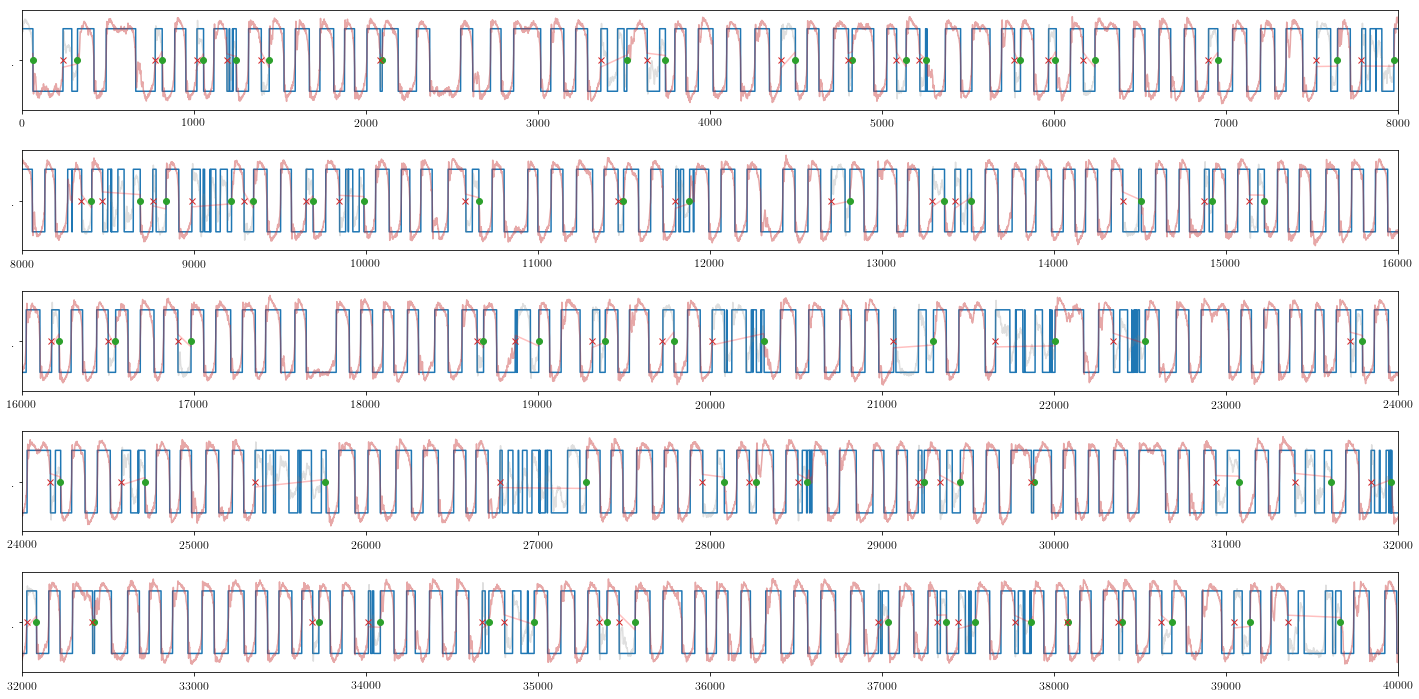

In [38]:
plt.rcParams['figure.figsize'] = (20.0, 10.0)

f, axes = plt.subplots(5, 1, sharey=False, sharex=False)
ax= np.ravel(axes)

for i in range(5):
    ax[i].plot(pod_pr3['t'].values, np.sign(pod_pr3['k1'].values))
    ax[i].plot(pod_pr3['t'].values, 4*pod_pr3['k1'].values, 'grey', alpha=0.25)
    ax[i].plot(pod_pr3_cr['t'].values, 4*pod_pr3_cr['k1'].values, 'red', '.', alpha=0.25)
    ax[i].plot(times_cr,np.zeros_like(times_cr), 'o')
    ax[i].plot(times_ec,np.zeros_like(times_ec), 'x')
    ax[i].set_xlim([i*8000,(i+1)*8000])
    
plt.tight_layout()

What is the maximum lenght we can use? 

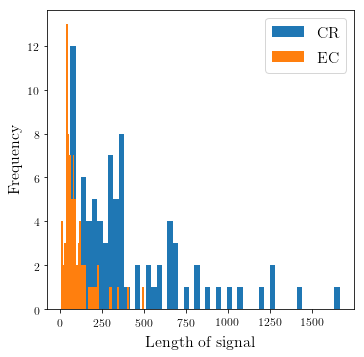

In [39]:
length_cr = []
for i in times_cr:
    minj = 1e30
    for j in times_ec:
        if (j-i > 0):
            minj = np.min([j - i, minj])
    length_cr.append(minj)

plt.rcParams['figure.figsize'] = (5.5, 5.5)
f, ax = plt.subplots(1, 1, sharey=False, sharex=False)

    
plt.hist(length_cr[:-1],50)

length_ec = []
for i in times_ec:
    minj = 1e30
    for j in times_cr:
        if (j-i > 0):
            minj = np.min([j - i, minj])
    length_ec.append(minj)

plt.hist(length_ec[:-1],50)
plt.xlabel('Length of signal')
plt.ylabel('Frequency')
plt.legend(['CR', 'EC'])
plt.show()

In [40]:
len=20*100

pod_pr3_contiguous_cr = pd.DataFrame(columns=['t', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
pod_pr3_contiguous_cr.t = [np.arange(len)/20.]
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    x = np.zeros((len,count_cr))
    for j in range(count_cr):
        idx=pod_pr3.query('t==11+'+str(times_cr[j])).index[0]
        #x[:,j] = np.sign(pod_pr3[k].loc[idx:idx+len-1].values)
        x[:,j] = pod_pr3[k].loc[idx:idx+len-1].values
    
    pod_pr3_contiguous_cr[k] = [x]


In [41]:
len=20*100

pod_pr3_contiguous_ec = pd.DataFrame(columns=['t', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
pod_pr3_contiguous_ec.t = [np.arange(len)/20.]

for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    x = np.zeros((len,count_ec))
    for j in range(count_ec):
        idx=pod_pr3.query('t==11+'+str(times_ec[j])).index[0]
        #x[:,j] = np.sign(pod_pr3[k].loc[idx:idx+len-1].values)
        x[:,j] = pod_pr3[k].loc[idx:idx+len-1].values
    
    pod_pr3_contiguous_ec[k] = [x]

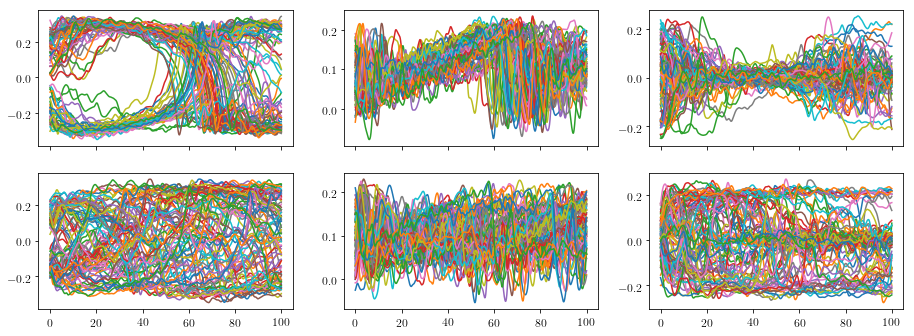

In [42]:
plt.rcParams['figure.figsize'] = (15.5, 5.5)

f, axes = plt.subplots(2, 3, sharey=False, sharex=True)
ax= np.ravel(axes)

ax[0].plot(pod_pr3_contiguous_cr.t[0], pod_pr3_contiguous_cr.k1[0])
ax[1].plot(pod_pr3_contiguous_cr.t[0], pod_pr3_contiguous_cr.k2[0])
ax[2].plot(pod_pr3_contiguous_cr.t[0], pod_pr3_contiguous_cr.k4[0])

ax[3].plot(pod_pr3_contiguous_ec.t[0], pod_pr3_contiguous_ec.k1[0])
ax[4].plot(pod_pr3_contiguous_ec.t[0], pod_pr3_contiguous_ec.k2[0])
ax[5].plot(pod_pr3_contiguous_ec.t[0], pod_pr3_contiguous_ec.k4[0])

plt.show()

In [43]:
psd_pr3_contiguous_cr = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
psd_pr3_contiguous_ec = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])

n = len
m = int(len/2)
nperseg=n

#psd_pr3_contiguous_cr['f'] = [np.fft.fftfreq(n, fsampling)[0:m]]
#psd_pr3_contiguous_ec['f'] = [np.fft.fftfreq(n, fsampling)[0:m]]

psd_pr3_contiguous_cr.f = [signal.welch(pod_pr3_contiguous_cr['k1'][0][:,:], 1./fsampling, nperseg=nperseg, axis=0)[0]]
psd_pr3_contiguous_ec.f = [signal.welch(pod_pr3_contiguous_ec['k1'][0][:,:], 1./fsampling, nperseg=nperseg, axis=0)[0]]

for k in ['k1', 'k2', 'k3', 'k4', 'k5', 'k6']:
    #psd_pr3_contiguous_cr[k] = [np.abs(np.fft.fft(pod_pr3_contiguous_cr[k][0][:,:], axis=0)[0:m])**2.]
    #psd_pr3_contiguous_ec[k] = [np.abs(np.fft.fft(pod_pr3_contiguous_ec[k][0][:,:], axis=0)[0:m])**2.]
    
    psd_pr3_contiguous_cr[k] = [signal.welch(pod_pr3_contiguous_cr[k][0][:,:], 1./fsampling, nperseg=nperseg, axis=0)[1]]
    psd_pr3_contiguous_ec[k] = [signal.welch(pod_pr3_contiguous_ec[k][0][:,:], 1./fsampling, nperseg=nperseg, axis=0)[1]]
    
    

/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: divide by zero encountered in power
  import sys


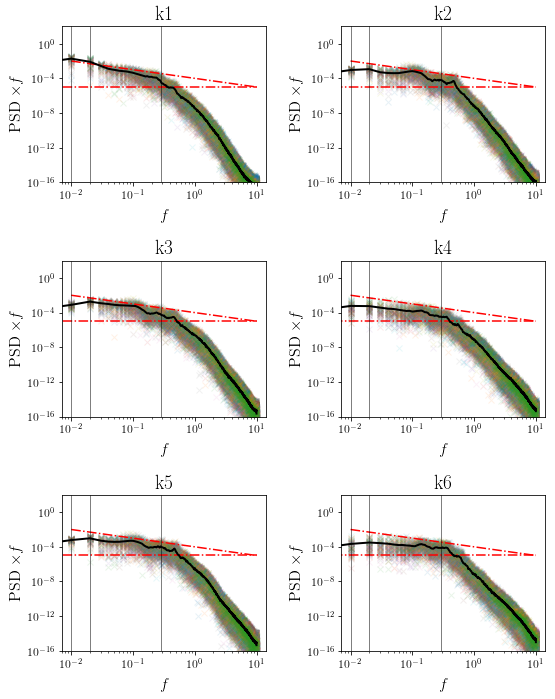

In [44]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], psd_pr3_contiguous_cr[k][0]*np.power(psd_pr3_contiguous_cr.f[0].reshape([-1,1]),1.0), 'x', alpha=0.1, rasterized=True)
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], 1e-4*np.power(psd_pr3_contiguous_cr.f[0],-1), 'r', linestyle='-.')
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], 1e-5*np.power(psd_pr3_contiguous_cr.f[0],0), 'r', linestyle='-.')
    
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], np.mean(psd_pr3_contiguous_cr[k][0]*np.power(psd_pr3_contiguous_cr.f[0].reshape([-1,1]),1.0), axis=1), 'k', linewidth=2.0)    
    ax[i].set_ylim([1e-16, 1e2])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD $\\times f$')
    ax[i].set_title(k)
    
    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)    

plt.tight_layout()

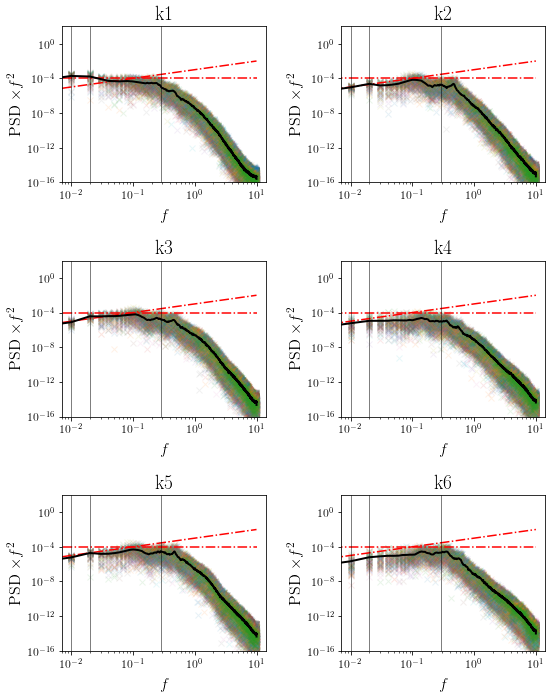

In [45]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], psd_pr3_contiguous_cr[k][0]*np.power(psd_pr3_contiguous_cr.f[0].reshape([-1,1]),2.0), 'x', alpha=0.1, rasterized=True)
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], 1e-4*np.power(psd_pr3_contiguous_cr.f[0],0), 'r', linestyle='-.')
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], 1e-3*np.power(psd_pr3_contiguous_cr.f[0],1), 'r', linestyle='-.')
    
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], np.mean(psd_pr3_contiguous_cr[k][0]*np.power(psd_pr3_contiguous_cr.f[0].reshape([-1,1]),2.0), axis=1), 'k', linewidth=2.0)    
    ax[i].set_ylim([1e-16, 1e2])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD $\\times f^2$')
    ax[i].set_title(k)

    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)    
    
plt.tight_layout()

/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: divide by zero encountered in power
  import sys


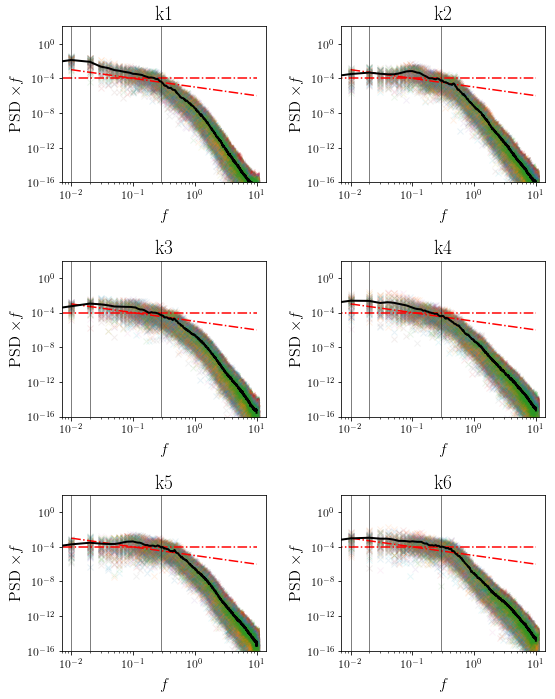

In [46]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], psd_pr3_contiguous_ec[k][0]*np.power(psd_pr3_contiguous_ec.f[0].reshape([-1,1]),1.0), 'x', alpha=0.1, rasterized=True)
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], 1e-5*np.power(psd_pr3_contiguous_ec.f[0],-1), 'r', linestyle='-.')
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], 1e-4*np.power(psd_pr3_contiguous_ec.f[0],0), 'r', linestyle='-.')
    
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], np.mean(psd_pr3_contiguous_ec[k][0]*np.power(psd_pr3_contiguous_ec.f[0].reshape([-1,1]),1.0), axis=1), 'k', linewidth=2.0)    
    ax[i].set_ylim([1e-16, 1e2])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD $\\times f$')
    ax[i].set_title(k)

    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)    
    
plt.tight_layout()

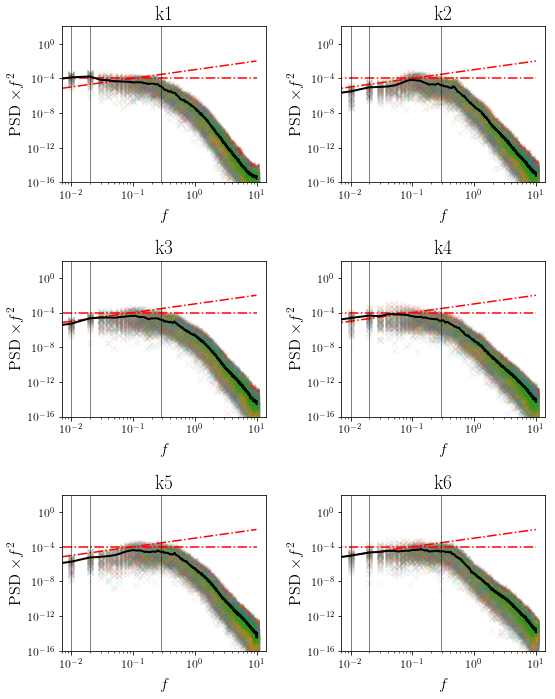

In [47]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], psd_pr3_contiguous_ec[k][0]*np.power(psd_pr3_contiguous_ec.f[0].reshape([-1,1]),2.0), 'x', alpha=0.1, rasterized=True)
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], 1e-4*np.power(psd_pr3_contiguous_ec.f[0],0), 'r', linestyle='-.')
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], 1e-3*np.power(psd_pr3_contiguous_ec.f[0],1), 'r', linestyle='-.')
    
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], np.mean(psd_pr3_contiguous_ec[k][0]*np.power(psd_pr3_contiguous_ec.f[0].reshape([-1,1]),2.0), axis=1), 'k', linewidth=2.0)    
    ax[i].set_ylim([1e-16, 1e2])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD $\\times f^2$')
    ax[i].set_title(k)

    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)
    
plt.tight_layout()

Now, we try only using the signs of the modal coefficients

In [48]:
len=20*100

pod_pr3_contiguous_cr = pd.DataFrame(columns=['t', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
pod_pr3_contiguous_cr.t = [np.arange(len)/20.]
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    x = np.zeros((len,count_cr))
    for j in range(count_cr):
        idx=pod_pr3.query('t==11+'+str(times_cr[j])).index[0]
        x[:,j] = np.sign(pod_pr3[k].loc[idx:idx+len-1].values)            
    pod_pr3_contiguous_cr[k] = [x]


In [49]:
len=20*100

pod_pr3_contiguous_ec = pd.DataFrame(columns=['t', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
pod_pr3_contiguous_ec.t = [np.arange(len)/20.]

for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    x = np.zeros((len,count_ec))
    for j in range(count_ec):
        idx=pod_pr3.query('t==11+'+str(times_ec[j])).index[0]
        x[:,j] = np.sign(pod_pr3[k].loc[idx:idx+len-1].values)
        
    
    pod_pr3_contiguous_ec[k] = [x]

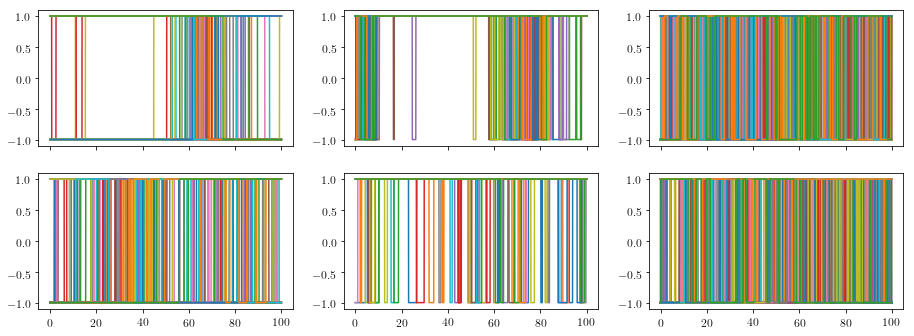

In [50]:
plt.rcParams['figure.figsize'] = (15.5, 5.5)

f, axes = plt.subplots(2, 3, sharey=False, sharex=True)
ax= np.ravel(axes)

ax[0].plot(pod_pr3_contiguous_cr.t[0], pod_pr3_contiguous_cr.k1[0])
ax[1].plot(pod_pr3_contiguous_cr.t[0], pod_pr3_contiguous_cr.k2[0])
ax[2].plot(pod_pr3_contiguous_cr.t[0], pod_pr3_contiguous_cr.k4[0])

ax[3].plot(pod_pr3_contiguous_ec.t[0], pod_pr3_contiguous_ec.k1[0])
ax[4].plot(pod_pr3_contiguous_ec.t[0], pod_pr3_contiguous_ec.k2[0])
ax[5].plot(pod_pr3_contiguous_ec.t[0], pod_pr3_contiguous_ec.k4[0])

plt.show()

In [51]:
psd_pr3_contiguous_cr = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])
psd_pr3_contiguous_ec = pd.DataFrame(columns=['f', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6'])

n = len
m = int(len/2)
nperseg=n

#psd_pr3_contiguous_cr['f'] = [np.fft.fftfreq(n, fsampling)[0:m]]
#psd_pr3_contiguous_ec['f'] = [np.fft.fftfreq(n, fsampling)[0:m]]

psd_pr3_contiguous_cr.f = [signal.welch(pod_pr3_contiguous_cr['k1'][0][:,:], 1./fsampling, nperseg=nperseg, axis=0)[0]]
psd_pr3_contiguous_ec.f = [signal.welch(pod_pr3_contiguous_ec['k1'][0][:,:], 1./fsampling, nperseg=nperseg, axis=0)[0]]

for k in ['k1', 'k2', 'k3', 'k4', 'k5', 'k6']:
    #psd_pr3_contiguous_cr[k] = [np.abs(np.fft.fft(pod_pr3_contiguous_cr[k][0][:,:], axis=0)[0:m])**2.]
    #psd_pr3_contiguous_ec[k] = [np.abs(np.fft.fft(pod_pr3_contiguous_ec[k][0][:,:], axis=0)[0:m])**2.]
    
    psd_pr3_contiguous_cr[k] = [signal.welch(pod_pr3_contiguous_cr[k][0][:,:], 1./fsampling, nperseg=nperseg, axis=0)[1]]
    psd_pr3_contiguous_ec[k] = [signal.welch(pod_pr3_contiguous_ec[k][0][:,:], 1./fsampling, nperseg=nperseg, axis=0)[1]]
    
    

/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: divide by zero encountered in power
  import sys


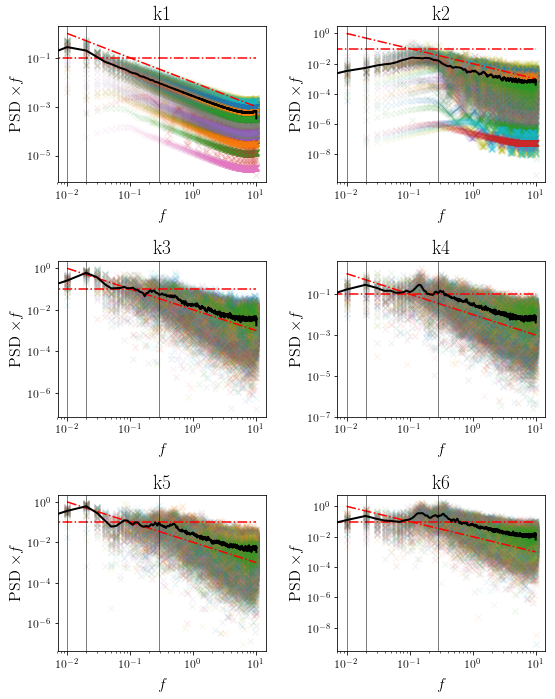

In [52]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], psd_pr3_contiguous_cr[k][0]*np.power(psd_pr3_contiguous_cr.f[0].reshape([-1,1]),1.0), 'x', alpha=0.1, rasterized=True)
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], 1e-2*np.power(psd_pr3_contiguous_cr.f[0],-1), 'r', linestyle='-.')
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], 1e-1*np.power(psd_pr3_contiguous_cr.f[0],0), 'r', linestyle='-.')
    
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], np.mean(psd_pr3_contiguous_cr[k][0]*np.power(psd_pr3_contiguous_cr.f[0].reshape([-1,1]),1.0), axis=1), 'k', linewidth=2.0)    
    #ax[i].set_ylim([1e-6, 1e4])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD $\\times f$')
    ax[i].set_title(k)
    
    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)    

plt.tight_layout()

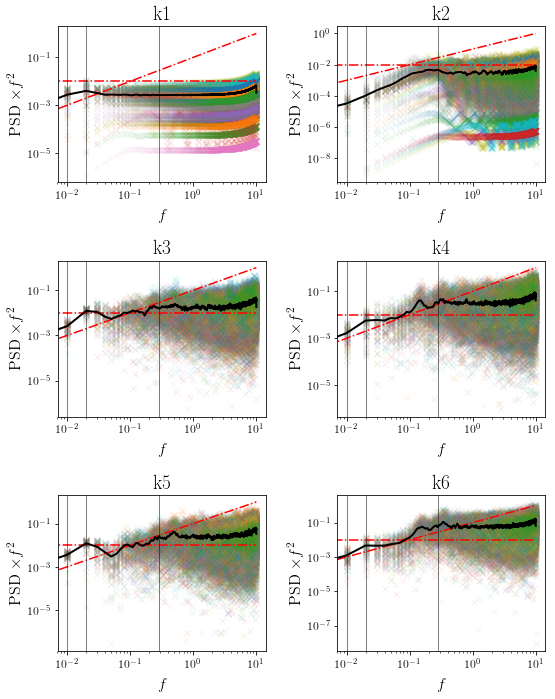

In [53]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], psd_pr3_contiguous_cr[k][0]*np.power(psd_pr3_contiguous_cr.f[0].reshape([-1,1]),2.0), 'x', alpha=0.1, rasterized=True)
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], 1e-2*np.power(psd_pr3_contiguous_cr.f[0],0), 'r', linestyle='-.')
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], 1e-1*np.power(psd_pr3_contiguous_cr.f[0],1), 'r', linestyle='-.')
    
    ax[i].loglog(psd_pr3_contiguous_cr.f[0], np.mean(psd_pr3_contiguous_cr[k][0]*np.power(psd_pr3_contiguous_cr.f[0].reshape([-1,1]),2.0), axis=1), 'k', linewidth=2.0)    
    #ax[i].set_ylim([1e-6, 1e4])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD $\\times f^2$')
    ax[i].set_title(k)

    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)    
    
plt.tight_layout()

/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: divide by zero encountered in power
  import sys


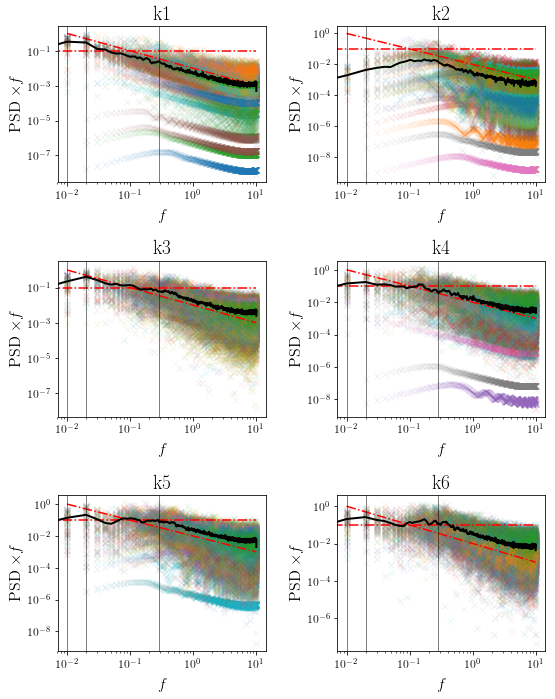

In [54]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], psd_pr3_contiguous_ec[k][0]*np.power(psd_pr3_contiguous_ec.f[0].reshape([-1,1]),1.0), 'x', alpha=0.1, rasterized=True)
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], 1e-2*np.power(psd_pr3_contiguous_ec.f[0],-1), 'r', linestyle='-.')
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], 1e-1*np.power(psd_pr3_contiguous_ec.f[0],0), 'r', linestyle='-.')
    
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], np.mean(psd_pr3_contiguous_ec[k][0]*np.power(psd_pr3_contiguous_ec.f[0].reshape([-1,1]),1.0), axis=1), 'k', linewidth=2.0)    
    #ax[i].set_ylim([1e-6, 1e4])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD $\\times f$')
    ax[i].set_title(k)

    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)    
    
plt.tight_layout()

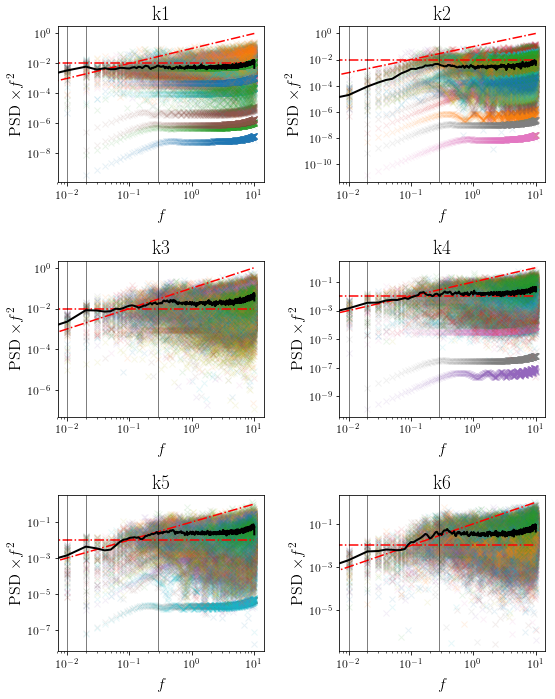

In [55]:
plt.rcParams['figure.figsize'] = (8.0, 10.0)

f, axes = plt.subplots(3, 2, sharey=False, sharex=False)
ax= np.ravel(axes)
for i, k in enumerate(['k1', 'k2', 'k3', 'k4', 'k5', 'k6']):    
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], psd_pr3_contiguous_ec[k][0]*np.power(psd_pr3_contiguous_ec.f[0].reshape([-1,1]),2.0), 'x', alpha=0.1, rasterized=True)
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], 1e-2*np.power(psd_pr3_contiguous_ec.f[0],0), 'r', linestyle='-.')
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], 1e-1*np.power(psd_pr3_contiguous_ec.f[0],1), 'r', linestyle='-.')
    
    ax[i].loglog(psd_pr3_contiguous_ec.f[0], np.mean(psd_pr3_contiguous_ec[k][0]*np.power(psd_pr3_contiguous_ec.f[0].reshape([-1,1]),2.0), axis=1), 'k', linewidth=2.0)    
    #ax[i].set_ylim([1e-6, 1e4])
    ax[i].set_xlabel('$f$')
    ax[i].set_ylabel('PSD $\\times f^2$')
    ax[i].set_title(k)

    ax[i].axvline(x=1/3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=1/50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=1/100.0, color='k', linewidth=0.5)
    
plt.tight_layout()

# (Parenthesis) Distribution of waiting times

In [56]:
zero1_pr43 = pd.read_hdf('./results_from_waiting_times/zero1_pr43.h5')
zero1_pr3 = pd.read_hdf('./results_from_waiting_times/zero1_pr3.h5')

zero2_pr43 = pd.read_hdf('./results_from_waiting_times/zero2_pr43.h5')
zero2_pr3 = pd.read_hdf('./results_from_waiting_times/zero2_pr3.h5')

zero3_pr43 = pd.read_hdf('./results_from_waiting_times/zero3_pr43.h5')
zero3_pr3 = pd.read_hdf('./results_from_waiting_times/zero3_pr3.h5')

zero4_pr43 = pd.read_hdf('./results_from_waiting_times/zero4_pr43.h5')
zero4_pr3 = pd.read_hdf('./results_from_waiting_times/zero4_pr3.h5')

In [57]:
def get_gamma_fits(zero,tau2):
    from scipy.stats import gamma
    
    shape, loc, scale = gamma.fit(zero.tau,floc=0)
    n = zero.tau.count()
    fitted = pd.Series([n, shape, scale, scale*shape, loc], 
                       index=['n', 'k', 'theta', 'm', 'loc'])
    
    s = gamma.pdf(tau2, shape, loc, scale)
    c = gamma.cdf(tau2, shape, loc, scale)
        
    shape, loc, scale = gamma.fit(zero.loc[zero.isrev==True].tau,floc=0)
    n = zero.loc[zero.isrev==True].tau.count()
    fitted_cr = pd.Series([n, shape, scale, scale*shape, loc], 
                       index=['n', 'k', 'theta', 'm', 'loc'])
    
    s_cr = gamma.pdf(tau2, shape, loc, scale)    
    c_cr = gamma.cdf(tau2, shape, loc, scale)
    
    shape, loc, scale = gamma.fit(zero.loc[zero.isrev==False].tau,floc=0)
    n = zero.loc[zero.isrev==False].tau.count()    
    fitted_ec = pd.Series([n, shape, scale, scale*shape, loc], 
                       index=['n', 'k', 'theta', 'm', 'loc'])
    s_ec = gamma.pdf(tau2, shape, loc, scale)    
    c_ec = gamma.cdf(tau2, shape, loc, scale)

    return fitted, s, fitted_cr, s_cr, fitted_ec, s_ec, c_cr, c_ec

def get_expon_fits(zero,tau2):
    from scipy.stats import expon
    
    loc, scale = expon.fit(zero.tau,floc=0)
    n = zero.tau.count()
    fitted = pd.Series([n, scale, loc], 
                       index=['n', 'm', 'loc'])
    
    s = expon.pdf(tau2, loc, scale)
    c = expon.cdf(tau2, loc, scale)
        
    loc, scale = expon.fit(zero.loc[zero.isrev==True].tau,floc=0)
    n = zero.loc[zero.isrev==True].tau.count()
    fitted_cr =  pd.Series([n, scale, loc], 
                       index=['n', 'm', 'loc'])
    
    s_cr = expon.pdf(tau2, loc, scale)    
    c_cr = expon.cdf(tau2, loc, scale)    
    
    loc, scale = expon.fit(zero.loc[zero.isrev==False].tau,floc=0)
    n = zero.loc[zero.isrev==False].tau.count()    
    fitted_ec =  pd.Series([n, scale, loc], 
                       index=['n', 'm', 'loc'])
    s_ec = expon.pdf(tau2, loc, scale)    
    c_ec = expon.cdf(tau2, loc, scale)    

    return fitted, s, fitted_cr, s_cr, fitted_ec, s_ec, c_cr, c_ec

def get_powerlaw_fits(zero,tau2):
    from scipy.stats import powerlaw
    
    shape, loc, scale = powerlaw.fit(zero.tau,floc=0)
    n = zero.tau.count()
    fitted = pd.Series([n, shape,  scale, loc], 
                       index=['n', 'shape', 'm', 'loc'])
    
    s = powerlaw.pdf(tau2, shape, loc, scale)
    c = powerlaw.cdf(tau2, shape, loc, scale)
        
    shape, loc, scale = powerlaw.fit(zero.loc[zero.isrev==True].tau,floc=0)
    n = zero.loc[zero.isrev==True].tau.count()
    fitted_cr =   pd.Series([n, shape,  scale, loc], 
                       index=['n', 'shape', 'm', 'loc'])
    
    s_cr = powerlaw.pdf(tau2, shape, loc, scale)    
    c_cr = powerlaw.cdf(tau2, shape, loc, scale)    
    
    shape, loc, scale = powerlaw.fit(zero.loc[zero.isrev==False].tau,floc=0)
    n = zero.loc[zero.isrev==False].tau.count()    
    fitted_ec =  pd.Series([n, shape,  scale, loc], 
                       index=['n', 'shape', 'm', 'loc'])
    s_ec = powerlaw.pdf(tau2, shape, loc, scale)    
    c_ec = powerlaw.cdf(tau2, shape, loc, scale)    

    return fitted, s, fitted_cr, s_cr, fitted_ec, s_ec, c_cr, c_ec


def get_lognorm_fits(zero,tau2):
    from scipy.stats import lognorm
    
    shape, loc, scale = lognorm.fit(zero.tau,floc=0)
    n = zero.tau.count()
    fitted = pd.Series([n, shape,  scale, loc], 
                       index=['n', 'shape', 'm', 'loc'])
    
    s = lognorm.pdf(tau2, shape, loc, scale)
    c = lognorm.cdf(tau2, shape, loc, scale)
        
    shape, loc, scale = lognorm.fit(zero.loc[zero.isrev==True].tau,floc=0)
    n = zero.loc[zero.isrev==True].tau.count()
    fitted_cr =   pd.Series([n, shape,  scale, loc], 
                       index=['n', 'shape', 'm', 'loc'])
    
    s_cr = lognorm.pdf(tau2, shape, loc, scale)    
    c_cr = lognorm.cdf(tau2, shape, loc, scale)    
    
    shape, loc, scale = lognorm.fit(zero.loc[zero.isrev==False].tau,floc=0)
    n = zero.loc[zero.isrev==False].tau.count()    
    fitted_ec =  pd.Series([n, shape,  scale, loc], 
                       index=['n', 'shape', 'm', 'loc'])
    s_ec = lognorm.pdf(tau2, shape, loc, scale)    
    c_ec = lognorm.cdf(tau2, shape, loc, scale)    

    return fitted, s, fitted_cr, s_cr, fitted_ec, s_ec, c_cr, c_ec

def get_fatigue_fits(zero,tau2):
    from scipy.stats import fatiguelife
    
    shape, loc, scale = fatiguelife.fit(zero.tau,floc=0)
    n = zero.tau.count()
    fitted = pd.Series([n, shape,  scale, loc], 
                       index=['n', 'shape', 'm', 'loc'])
    
    s = fatiguelife.pdf(tau2, shape, loc, scale)
    c = fatiguelife.cdf(tau2, shape, loc, scale)
        
    shape, loc, scale = fatiguelife.fit(zero.loc[zero.isrev==True].tau,floc=0)
    n = zero.loc[zero.isrev==True].tau.count()
    fitted_cr =   pd.Series([n, shape,  scale, loc], 
                       index=['n', 'shape', 'm', 'loc'])
    
    s_cr = fatiguelife.pdf(tau2, shape, loc, scale)    
    c_cr = fatiguelife.cdf(tau2, shape, loc, scale)    
    
    shape, loc, scale = fatiguelife.fit(zero.loc[zero.isrev==False].tau,floc=0)
    n = zero.loc[zero.isrev==False].tau.count()    
    fitted_ec =  pd.Series([n, shape,  scale, loc], 
                       index=['n', 'shape', 'm', 'loc'])
    s_ec = fatiguelife.pdf(tau2, shape, loc, scale)    
    c_ec = fatiguelife.cdf(tau2, shape, loc, scale)    

    return fitted, s, fitted_cr, s_cr, fitted_ec, s_ec, c_cr, c_ec

In [58]:
tau = np.linspace(0,400,40000)
f1_pr43, s1_pr43, f1_cr_pr43, s1_cr_pr43, f1_ec_pr43, s1_ec_pr43, c1_cr_pr43, c1_ec_pr43 = get_gamma_fits(zero1_pr43, tau)
f2_pr43, s2_pr43, f2_cr_pr43, s2_cr_pr43, f2_ec_pr43, s2_ec_pr43, c2_cr_pr43, c2_ec_pr43 = get_gamma_fits(zero2_pr43, tau)
f3_pr43, s3_pr43, f3_cr_pr43, s3_cr_pr43, f3_ec_pr43, s3_ec_pr43, c3_cr_pr43, c3_ec_pr43 = get_gamma_fits(zero3_pr43, tau)
f4_pr43, s4_pr43, f4_cr_pr43, s4_cr_pr43, f4_ec_pr43, s4_ec_pr43, c4_cr_pr43, c4_ec_pr43 = get_gamma_fits(zero4_pr43, tau)

f1_pr3, s1_pr3, f1_cr_pr3, s1_cr_pr3, f1_ec_pr3, s1_ec_pr3, c1_cr_pr3, c1_ec_pr3 = get_gamma_fits(zero1_pr3, tau)
f2_pr3, s2_pr3, f2_cr_pr3, s2_cr_pr3, f2_ec_pr3, s2_ec_pr3, c2_cr_pr3, c2_ec_pr3 = get_gamma_fits(zero2_pr3, tau)
f3_pr3, s3_pr3, f3_cr_pr3, s3_cr_pr3, f3_ec_pr3, s3_ec_pr3, c3_cr_pr3, c3_ec_pr3 = get_gamma_fits(zero3_pr3, tau)
f4_pr3, s4_pr3, f4_cr_pr3, s4_cr_pr3, f4_ec_pr3, s4_ec_pr3, c4_cr_pr3, c4_ec_pr3 = get_gamma_fits(zero4_pr3, tau)

In [59]:
f1_pr43, s1_pr43, f1_cr_pr43, s1_cr_pr43, f1_ec_pr43, s1_ec_pr43, c1_cr_pr43, c1_ec_pr43 = get_expon_fits(zero1_pr43, tau)
f2_pr43, s2_pr43, f2_cr_pr43, s2_cr_pr43, f2_ec_pr43, s2_ec_pr43, c2_cr_pr43, c2_ec_pr43 = get_expon_fits(zero2_pr43, tau)
f3_pr43, s3_pr43, f3_cr_pr43, s3_cr_pr43, f3_ec_pr43, s3_ec_pr43, c3_cr_pr43, c3_ec_pr43 = get_expon_fits(zero3_pr43, tau)
f4_pr43, s4_pr43, f4_cr_pr43, s4_cr_pr43, f4_ec_pr43, s4_ec_pr43, c4_cr_pr43, c4_ec_pr43 = get_expon_fits(zero4_pr43, tau)

f1_pr3, s1_pr3, f1_cr_pr3, s1_cr_pr3, f1_ec_pr3, s1_ec_pr3, c1_cr_pr3, c1_ec_pr3 = get_expon_fits(zero1_pr3, tau)
f2_pr3, s2_pr3, f2_cr_pr3, s2_cr_pr3, f2_ec_pr3, s2_ec_pr3, c2_cr_pr3, c2_ec_pr3 = get_expon_fits(zero2_pr3, tau)
f3_pr3, s3_pr3, f3_cr_pr3, s3_cr_pr3, f3_ec_pr3, s3_ec_pr3, c3_cr_pr3, c3_ec_pr3 = get_expon_fits(zero3_pr3, tau)
f4_pr3, s4_pr3, f4_cr_pr3, s4_cr_pr3, f4_ec_pr3, s4_ec_pr3, c4_cr_pr3, c4_ec_pr3 = get_expon_fits(zero4_pr3, tau)

In [60]:
f1_pr43, s1_pr43, f1_cr_pr43, s1_cr_pr43, f1_ec_pr43, s1_ec_pr43, c1_cr_pr43, c1_ec_pr43 = get_powerlaw_fits(zero1_pr43, tau)
f2_pr43, s2_pr43, f2_cr_pr43, s2_cr_pr43, f2_ec_pr43, s2_ec_pr43, c2_cr_pr43, c2_ec_pr43 = get_powerlaw_fits(zero2_pr43, tau)
f3_pr43, s3_pr43, f3_cr_pr43, s3_cr_pr43, f3_ec_pr43, s3_ec_pr43, c3_cr_pr43, c3_ec_pr43 = get_powerlaw_fits(zero3_pr43, tau)
f4_pr43, s4_pr43, f4_cr_pr43, s4_cr_pr43, f4_ec_pr43, s4_ec_pr43, c4_cr_pr43, c4_ec_pr43 = get_powerlaw_fits(zero4_pr43, tau)

f1_pr3, s1_pr3, f1_cr_pr3, s1_cr_pr3, f1_ec_pr3, s1_ec_pr3, c1_cr_pr3, c1_ec_pr3 = get_powerlaw_fits(zero1_pr3, tau)
f2_pr3, s2_pr3, f2_cr_pr3, s2_cr_pr3, f2_ec_pr3, s2_ec_pr3, c2_cr_pr3, c2_ec_pr3 = get_powerlaw_fits(zero2_pr3, tau)
f3_pr3, s3_pr3, f3_cr_pr3, s3_cr_pr3, f3_ec_pr3, s3_ec_pr3, c3_cr_pr3, c3_ec_pr3 = get_powerlaw_fits(zero3_pr3, tau)
f4_pr3, s4_pr3, f4_cr_pr3, s4_cr_pr3, f4_ec_pr3, s4_ec_pr3, c4_cr_pr3, c4_ec_pr3 = get_powerlaw_fits(zero4_pr3, tau)

/people/castillo/anaconda3/lib/python3.6/site-packages/scipy/stats/_continuous_distns.py:5109: RuntimeWarning: divide by zero encountered in power
  return a*x**(a-1.0)


In [61]:
f1_pr43, s1_pr43, f1_cr_pr43, s1_cr_pr43, f1_ec_pr43, s1_ec_pr43, c1_cr_pr43, c1_ec_pr43 = get_lognorm_fits(zero1_pr43, tau)
f2_pr43, s2_pr43, f2_cr_pr43, s2_cr_pr43, f2_ec_pr43, s2_ec_pr43, c2_cr_pr43, c2_ec_pr43 = get_lognorm_fits(zero2_pr43, tau)
f3_pr43, s3_pr43, f3_cr_pr43, s3_cr_pr43, f3_ec_pr43, s3_ec_pr43, c3_cr_pr43, c3_ec_pr43 = get_lognorm_fits(zero3_pr43, tau)
f4_pr43, s4_pr43, f4_cr_pr43, s4_cr_pr43, f4_ec_pr43, s4_ec_pr43, c4_cr_pr43, c4_ec_pr43 = get_lognorm_fits(zero4_pr43, tau)

f1_pr3, s1_pr3, f1_cr_pr3, s1_cr_pr3, f1_ec_pr3, s1_ec_pr3, c1_cr_pr3, c1_ec_pr3 = get_lognorm_fits(zero1_pr3, tau)
f2_pr3, s2_pr3, f2_cr_pr3, s2_cr_pr3, f2_ec_pr3, s2_ec_pr3, c2_cr_pr3, c2_ec_pr3 = get_lognorm_fits(zero2_pr3, tau)
f3_pr3, s3_pr3, f3_cr_pr3, s3_cr_pr3, f3_ec_pr3, s3_ec_pr3, c3_cr_pr3, c3_ec_pr3 = get_lognorm_fits(zero3_pr3, tau)
f4_pr3, s4_pr3, f4_cr_pr3, s4_cr_pr3, f4_ec_pr3, s4_ec_pr3, c4_cr_pr3, c4_ec_pr3 = get_lognorm_fits(zero4_pr3, tau)

In [62]:
f3_pr43, s3_pr43, f3a_cr_pr43, s3a_cr_pr43, f3a_ec_pr43, s3a_ec_pr43, c3a_cr_pr43, c3a_ec_pr43 = get_gamma_fits(zero3_pr43, tau)
f3_pr43, s3_pr43, f3b_cr_pr43, s3b_cr_pr43, f3b_ec_pr43, s3b_ec_pr43, c3b_cr_pr43, c3b_ec_pr43 = get_powerlaw_fits(zero3_pr43, tau)
f3_pr43, s3_pr43, f3c_cr_pr43, s3c_cr_pr43, f3c_ec_pr43, s3c_ec_pr43, c3c_cr_pr43, c3c_ec_pr43 = get_lognorm_fits(zero3_pr43, tau)
f3_pr43, s3_pr43, f3d_cr_pr43, s3d_cr_pr43, f3d_ec_pr43, s3d_ec_pr43, c3d_cr_pr43, c3d_ec_pr43 = get_fatigue_fits(zero3_pr43, tau)

f3_pr3, s3_pr3, f3a_cr_pr3, s3a_cr_pr3, f3a_ec_pr3, s3a_ec_pr3, c3a_cr_pr3, c3a_ec_pr3 = get_gamma_fits(zero3_pr3, tau)
f3_pr3, s3_pr3, f3b_cr_pr3, s3b_cr_pr3, f3b_ec_pr3, s3b_ec_pr3, c3b_cr_pr3, c3b_ec_pr3 = get_powerlaw_fits(zero3_pr3, tau)
f3_pr3, s3_pr3, f3c_cr_pr3, s3c_cr_pr3, f3c_ec_pr3, s3c_ec_pr3, c3c_cr_pr3, c3c_ec_pr3 = get_lognorm_fits(zero3_pr3, tau)
f3_pr3, s3_pr3, f3d_cr_pr3, s3d_cr_pr3, f3d_ec_pr3, s3d_ec_pr3, c3d_cr_pr3, c3d_ec_pr3 = get_fatigue_fits(zero3_pr3, tau)

/people/castillo/anaconda3/lib/python3.6/site-packages/scipy/stats/_continuous_distns.py:5109: RuntimeWarning: divide by zero encountered in power
  return a*x**(a-1.0)


In [63]:
f4_pr43, s4_pr43, f4a_cr_pr43, s4a_cr_pr43, f4a_ec_pr43, s4a_ec_pr43, c4a_cr_pr43, c4a_ec_pr43 = get_gamma_fits(zero4_pr43, tau)
f4_pr43, s4_pr43, f4b_cr_pr43, s4b_cr_pr43, f4b_ec_pr43, s4b_ec_pr43, c4b_cr_pr43, c4b_ec_pr43 = get_powerlaw_fits(zero4_pr43, tau)
f4_pr43, s4_pr43, f4c_cr_pr43, s4c_cr_pr43, f4c_ec_pr43, s4c_ec_pr43, c4c_cr_pr43, c4c_ec_pr43 = get_lognorm_fits(zero4_pr43, tau)
f4_pr43, s4_pr43, f4d_cr_pr43, s4d_cr_pr43, f4d_ec_pr43, s4d_ec_pr43, c4d_cr_pr43, c4d_ec_pr43 = get_fatigue_fits(zero4_pr43, tau)

f4_pr3, s4_pr3, f4a_cr_pr3, s4a_cr_pr3, f4a_ec_pr3, s4a_ec_pr3, c4a_cr_pr3, c4a_ec_pr3 = get_gamma_fits(zero4_pr3, tau)
f4_pr3, s4_pr3, f4b_cr_pr3, s4b_cr_pr3, f4b_ec_pr3, s4b_ec_pr3, c4b_cr_pr3, c4b_ec_pr3 = get_powerlaw_fits(zero4_pr3, tau)
f4_pr3, s4_pr3, f4c_cr_pr3, s4c_cr_pr3, f4c_ec_pr3, s4c_ec_pr3, c4c_cr_pr3, c4c_ec_pr3 = get_lognorm_fits(zero4_pr3, tau)
f4_pr3, s4_pr3, f4d_cr_pr3, s4d_cr_pr3, f4d_ec_pr3, s4d_ec_pr3, c4d_cr_pr3, c4d_ec_pr3 = get_fatigue_fits(zero4_pr3, tau)

/people/castillo/anaconda3/lib/python3.6/site-packages/scipy/stats/_continuous_distns.py:5109: RuntimeWarning: divide by zero encountered in power
  return a*x**(a-1.0)


/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: divide by zero encountered in power
  if sys.path[0] == '':
/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:21: RuntimeWarning: divide by zero encountered in power
/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:3129: UserWarning: Attempted to set non-positive xlimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive xlimits for log-scale axis; '


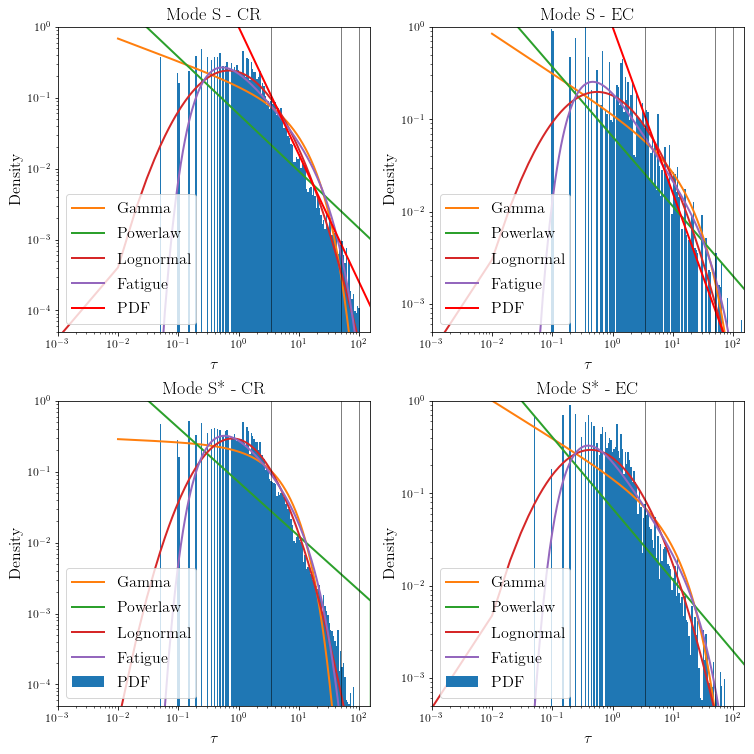

In [64]:
plt.rcParams['figure.figsize'] = (10.5, 10.5)

f, axes = plt.subplots(2,2, sharex=False, sharey=False)
ax= np.ravel(axes)


ax[0].hist(zero3_pr43.loc[zero3_pr43.isrev==True].tau,np.logspace(-3,3,256), density=True)
ax[0].loglog(tau, s3a_cr_pr43, linewidth=2.0)
ax[0].loglog(tau, s3b_cr_pr43, linewidth=2.0)
ax[0].loglog(tau, s3c_cr_pr43, linewidth=2.0)
ax[0].loglog(tau, s3d_cr_pr43, linewidth=2.0)
ax[0].loglog(tau, np.power(tau, -1.8), 'r', linewidth=2.0)
ax[0].set_ylim([5e-5,1e0])
ax[0].set_title('Mode S - CR', size=18)

ax[1].hist(zero3_pr43.loc[zero3_pr43.isrev==False].tau,np.logspace(-3,3,256), density=True)
ax[1].loglog(tau, s3a_ec_pr43, linewidth=2.0)
ax[1].loglog(tau, s3b_ec_pr43, linewidth=2.0)
ax[1].loglog(tau, s3c_ec_pr43, linewidth=2.0)
ax[1].loglog(tau, s3d_ec_pr43, linewidth=2.0)
ax[1].loglog(tau, np.power(tau, -1.8), 'r', linewidth=2.0)
ax[1].set_ylim([5e-4,1e0])
ax[1].set_title('Mode S - EC', size=18)

ax[2].hist(zero4_pr43.loc[zero4_pr43.isrev==True].tau,np.logspace(-3,3,256), density=True)
ax[2].loglog(tau, s4a_cr_pr43, linewidth=2.0)
ax[2].loglog(tau, s4b_cr_pr43, linewidth=2.0)
ax[2].loglog(tau, s4c_cr_pr43, linewidth=2.0)
ax[2].loglog(tau, s4d_cr_pr43, linewidth=2.0)
ax[2].set_ylim([5e-5,1e0])
ax[2].set_title('Mode S* - CR', size=18)

ax[3].hist(zero4_pr43.loc[zero4_pr43.isrev==False].tau,np.logspace(-3,3,256), density=True)
ax[3].loglog(tau, s4a_ec_pr43, linewidth=2.0)
ax[3].loglog(tau, s4b_ec_pr43, linewidth=2.0)
ax[3].loglog(tau, s4c_ec_pr43, linewidth=2.0)
ax[3].loglog(tau, s4d_ec_pr43, linewidth=2.0)

ax[3].set_ylim([5e-4,1e0])
ax[3].set_title('Mode S* - EC', size=18)

for i in range(4):
    ax[i].legend(['Gamma','Powerlaw', 'Lognormal', 'Fatigue',  'PDF'])

    ax[i].set_xlim([0,150])
    ax[i].set_xlabel('$\\tau$')
    ax[i].set_ylabel('Density')
    ax[i].axvline(x=3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=100.0, color='k', linewidth=0.5)

plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_c1.pdf',dpi=300)

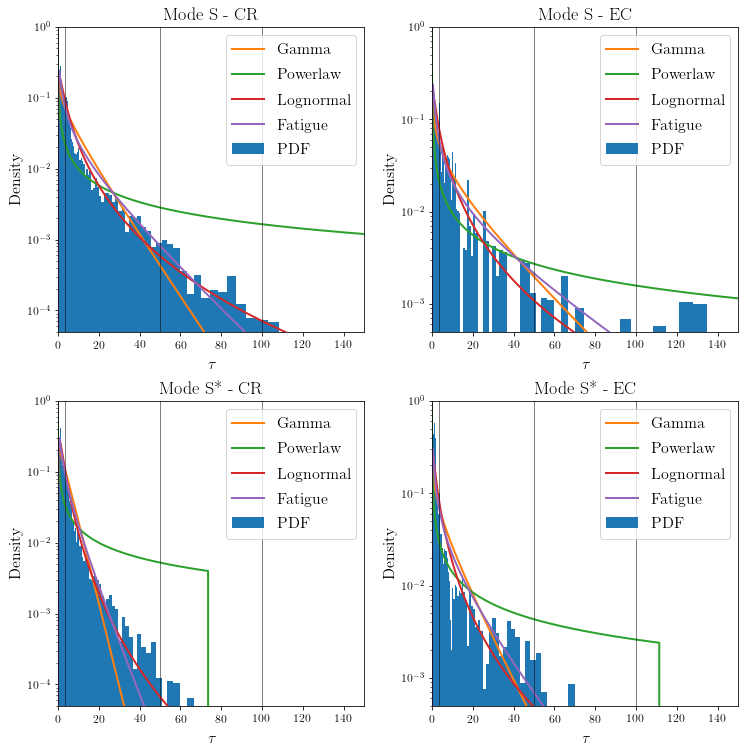

In [65]:
plt.rcParams['figure.figsize'] = (10.5, 10.5)

f, axes = plt.subplots(2,2, sharex=False, sharey=False)
ax= np.ravel(axes)


ax[0].hist(zero3_pr3.loc[zero3_pr3.isrev==True].tau,np.logspace(-3,3,256), density=True)
ax[0].semilogy(tau, s3a_cr_pr3, linewidth=2.0)
ax[0].semilogy(tau, s3b_cr_pr3, linewidth=2.0)
ax[0].semilogy(tau, s3c_cr_pr3, linewidth=2.0)
ax[0].semilogy(tau, s3d_cr_pr3, linewidth=2.0)
ax[0].set_ylim([5e-5,1e0])
ax[0].set_title('Mode S - CR', size=18)

ax[1].hist(zero3_pr3.loc[zero3_pr3.isrev==False].tau,np.logspace(-3,3,256), density=True)
ax[1].semilogy(tau, s3a_ec_pr3, linewidth=2.0)
ax[1].semilogy(tau, s3b_ec_pr3, linewidth=2.0)
ax[1].semilogy(tau, s3c_ec_pr3, linewidth=2.0)
ax[1].semilogy(tau, s3d_ec_pr3, linewidth=2.0)
ax[1].set_ylim([5e-4,1e0])
ax[1].set_title('Mode S - EC', size=18)

ax[2].hist(zero4_pr3.loc[zero4_pr3.isrev==True].tau,np.logspace(-3,3,256), density=True)
ax[2].semilogy(tau, s4a_cr_pr3, linewidth=2.0)
ax[2].semilogy(tau, s4b_cr_pr3, linewidth=2.0)
ax[2].semilogy(tau, s4c_cr_pr3, linewidth=2.0)
ax[2].semilogy(tau, s4d_cr_pr3, linewidth=2.0)
ax[2].set_ylim([5e-5,1e0])
ax[2].set_title('Mode S* - CR', size=18)

ax[3].hist(zero4_pr3.loc[zero4_pr3.isrev==False].tau,np.logspace(-3,3,256), density=True)
ax[3].semilogy(tau, s4a_ec_pr3, linewidth=2.0)
ax[3].semilogy(tau, s4b_ec_pr3, linewidth=2.0)
ax[3].semilogy(tau, s4c_ec_pr3, linewidth=2.0)
ax[3].semilogy(tau, s4d_ec_pr3, linewidth=2.0)
ax[3].set_ylim([5e-4,1e0])
ax[3].set_title('Mode S* - EC', size=18)

for i in range(4):
    ax[i].set_xlim([0,150])
    ax[i].set_xlabel('$\\tau$')
    ax[i].set_ylabel('Density')
    ax[i].legend(['Gamma','Powerlaw', 'Lognormal', 'Fatigue', 'PDF'])

    ax[i].axvline(x=3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=100.0, color='k', linewidth=0.5)

plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_c2.pdf',dpi=300)

/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:3129: UserWarning: Attempted to set non-positive xlimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive xlimits for log-scale axis; '


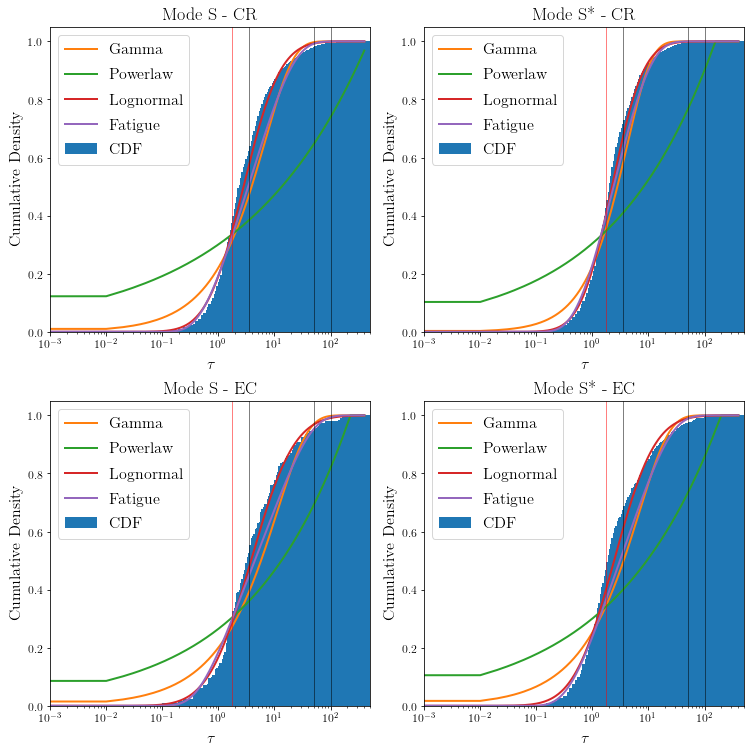

In [66]:
plt.rcParams['figure.figsize'] = (10.5, 10.5)

f, axes = plt.subplots(2,2, sharex=False, sharey=False)
ax= np.ravel(axes)


ax[0].hist(zero3_pr43.loc[zero3_pr43.isrev==True].tau, np.logspace(-3,3,256), cumulative=True, density=True)
ax[0].semilogx(tau, c3a_cr_pr43, linewidth=2.0)
ax[0].semilogx(tau, c3b_cr_pr43, linewidth=2.0)
ax[0].semilogx(tau, c3c_cr_pr43, linewidth=2.0)
ax[0].semilogx(tau, c3d_cr_pr43, linewidth=2.0)
ax[0].set_title('Mode S - CR', size=18)

ax[1].hist(zero4_pr43.loc[zero4_pr43.isrev==True].tau,np.logspace(-3,3,256), cumulative=True, density=True)
ax[1].semilogx(tau, c4a_cr_pr43, linewidth=2.0)
ax[1].semilogx(tau, c4b_cr_pr43, linewidth=2.0)
ax[1].semilogx(tau, c4c_cr_pr43, linewidth=2.0)
ax[1].semilogx(tau, c4d_cr_pr43, linewidth=2.0)
ax[1].set_title('Mode S* - CR', size=18)

ax[2].hist(zero3_pr43.loc[zero3_pr43.isrev==False].tau,np.logspace(-3,3,256), cumulative=True, density=True)
ax[2].semilogx(tau, c3a_ec_pr43, linewidth=2.0)
ax[2].semilogx(tau, c3b_ec_pr43, linewidth=2.0)
ax[2].semilogx(tau, c3c_ec_pr43, linewidth=2.0)
ax[2].semilogx(tau, c3d_ec_pr43, linewidth=2.0)
ax[2].set_title('Mode S - EC', size=18)

ax[3].hist(zero4_pr43.loc[zero4_pr43.isrev==False].tau,np.logspace(-3,3,256), cumulative=True, density=True)
ax[3].semilogx(tau, c4a_ec_pr43, linewidth=2.0)
ax[3].semilogx(tau, c4b_ec_pr43, linewidth=2.0)
ax[3].semilogx(tau, c4c_ec_pr43, linewidth=2.0)
ax[3].semilogx(tau, c4d_ec_pr43, linewidth=2.0)
ax[3].set_title('Mode S* - EC', size=18)

for i in range(4):
    ax[i].legend(['Gamma','Powerlaw', 'Lognormal', 'Fatigue', 'CDF'])
    ax[i].set_xlim([0,500])
    ax[i].set_xlabel('$\\tau$')
    ax[i].set_ylabel('Cumulative Density')

    ax[i].axvline(x=3.5/2, color='r', linewidth=0.5)    
    ax[i].axvline(x=3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=100.0, color='k', linewidth=0.5)

plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_c3.pdf',dpi=300)

/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:3129: UserWarning: Attempted to set non-positive xlimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive xlimits for log-scale axis; '


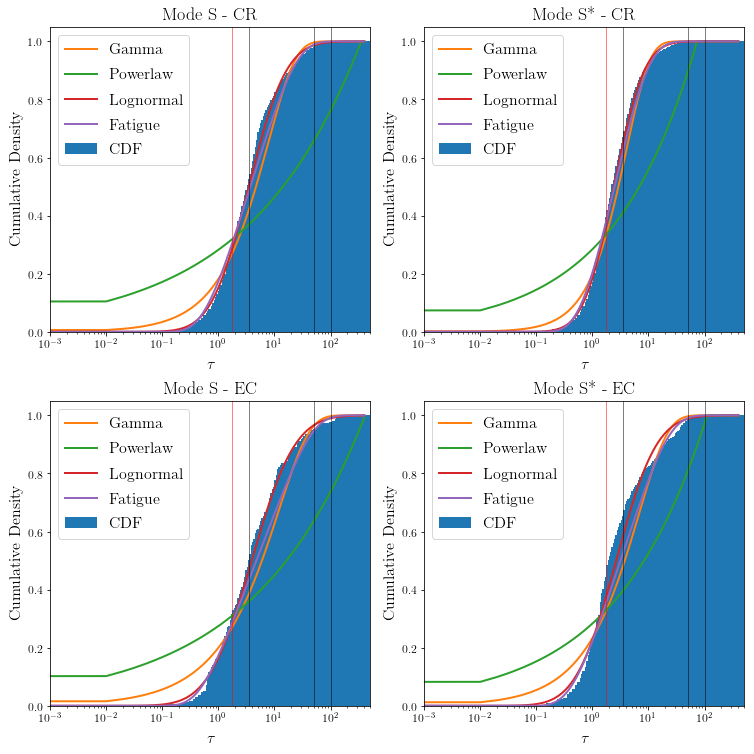

In [67]:
plt.rcParams['figure.figsize'] = (10.5, 10.5)

f, axes = plt.subplots(2,2, sharex=False, sharey=False)
ax= np.ravel(axes)


ax[0].hist(zero3_pr3.loc[zero3_pr3.isrev==True].tau, np.logspace(-3,3,256), cumulative=True, density=True)
ax[0].semilogx(tau, c3a_cr_pr3, linewidth=2.0)
ax[0].semilogx(tau, c3b_cr_pr3, linewidth=2.0)
ax[0].semilogx(tau, c3c_cr_pr3, linewidth=2.0)
ax[0].semilogx(tau, c3d_cr_pr3, linewidth=2.0)
ax[0].set_title('Mode S - CR', size=18)

ax[1].hist(zero4_pr3.loc[zero4_pr3.isrev==True].tau,np.logspace(-3,3,256), cumulative=True, density=True)
ax[1].semilogx(tau, c4a_cr_pr3, linewidth=2.0)
ax[1].semilogx(tau, c4b_cr_pr3, linewidth=2.0)
ax[1].semilogx(tau, c4c_cr_pr3, linewidth=2.0)
ax[1].semilogx(tau, c4d_cr_pr3, linewidth=2.0)
ax[1].set_title('Mode S* - CR', size=18)

ax[2].hist(zero3_pr3.loc[zero3_pr3.isrev==False].tau,np.logspace(-3,3,256), cumulative=True, density=True)
ax[2].semilogx(tau, c3a_ec_pr3, linewidth=2.0)
ax[2].semilogx(tau, c3b_ec_pr3, linewidth=2.0)
ax[2].semilogx(tau, c3c_ec_pr3, linewidth=2.0)
ax[2].semilogx(tau, c3d_ec_pr3, linewidth=2.0)
ax[2].set_title('Mode S - EC', size=18)

ax[3].hist(zero4_pr3.loc[zero4_pr3.isrev==False].tau,np.logspace(-3,3,256), cumulative=True, density=True)
ax[3].semilogx(tau, c4a_ec_pr3, linewidth=2.0)
ax[3].semilogx(tau, c4b_ec_pr3, linewidth=2.0)
ax[3].semilogx(tau, c4c_ec_pr3, linewidth=2.0)
ax[3].semilogx(tau, c4d_ec_pr3, linewidth=2.0)
ax[3].set_title('Mode S* - EC', size=18)

for i in range(4):
    ax[i].legend(['Gamma','Powerlaw', 'Lognormal', 'Fatigue', 'CDF'])
    ax[i].set_xlim([0,500])
    ax[i].set_xlabel('$\\tau$')
    ax[i].set_ylabel('Cumulative Density')

    ax[i].axvline(x=3.5/2, color='r', linewidth=0.5)    
    ax[i].axvline(x=3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=100.0, color='k', linewidth=0.5)

plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_c4.pdf',dpi=300)

/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in log
  if __name__ == '__main__':
/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:35: RuntimeWarning: divide by zero encountered in true_divide
/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:3129: UserWarning: Attempted to set non-positive xlimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive xlimits for log-scale axis; '


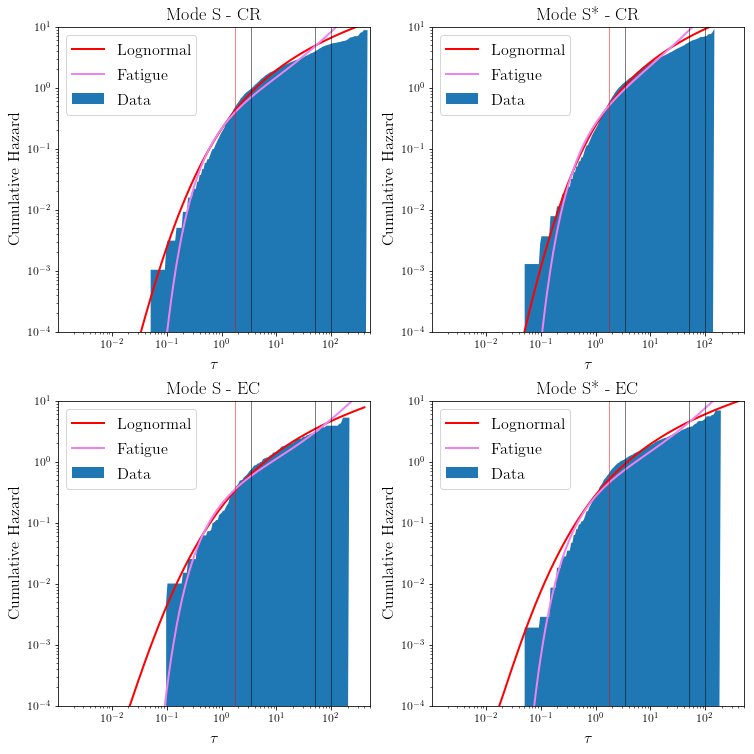

In [68]:
from scipy.integrate import cumtrapz

def get_cumulative_hazard(tau1):
    PDF = np.histogram(tau1.values, np.logspace(-3,3,256))
    CDF = np.cumsum(PDF[0])
    CDF = CDF/CDF[-1]
    
    x = 0.5*(PDF[1][1:]+PDF[1][:-1])
    y = -np.log(1-CDF)
    
    return x, y

plt.rcParams['figure.figsize'] = (10.5, 10.5)

f, axes = plt.subplots(2,2, sharex=False, sharey=False)
ax= np.ravel(axes)

x1, y1 = get_cumulative_hazard(zero3_pr43.loc[zero3_pr43.isrev==True].tau)
x2, y2 = get_cumulative_hazard(zero4_pr43.loc[zero4_pr43.isrev==True].tau)
x3, y3 = get_cumulative_hazard(zero3_pr43.loc[zero3_pr43.isrev==False].tau)
x4, y4 = get_cumulative_hazard(zero4_pr43.loc[zero4_pr43.isrev==False].tau)


ax[0].fill(x1, y1)
ax[1].fill(x2, y2)
ax[2].fill(x3, y3)
ax[3].fill(x4, y4)

ax[0].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s3c_cr_pr43/(1-c3c_cr_pr43), x=tau), 'r', linewidth=2.0)
ax[1].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s4c_cr_pr43/(1-c4c_cr_pr43), x=tau), 'r', linewidth=2.0)
ax[2].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s3c_ec_pr43/(1-c3c_ec_pr43), x=tau), 'r', linewidth=2.0)
ax[3].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s4c_ec_pr43/(1-c4c_ec_pr43), x=tau), 'r', linewidth=2.0)

ax[0].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s3d_cr_pr43/(1-c3d_cr_pr43), x=tau), 'violet', linewidth=2.0)
ax[1].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s4d_cr_pr43/(1-c4d_cr_pr43), x=tau), 'violet', linewidth=2.0)
ax[2].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s3d_ec_pr43/(1-c3d_ec_pr43), x=tau), 'violet', linewidth=2.0)
ax[3].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s4d_ec_pr43/(1-c4d_ec_pr43), x=tau), 'violet', linewidth=2.0)

ax[0].set_title('Mode S - CR', size=18)
ax[1].set_title('Mode S* - CR', size=18)
ax[2].set_title('Mode S - EC', size=18)
ax[3].set_title('Mode S* - EC', size=18)

for i in range(4):
    ax[i].legend(['Lognormal', 'Fatigue', 'Data'])

    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlabel('$\\tau$')
    ax[i].set_ylabel('Cumulative Hazard')
    ax[i].set_xlim([0,500])
    ax[i].set_ylim([1e-4,1e1])

    ax[i].axvline(x=3.5/2, color='r', linewidth=0.5)
    ax[i].axvline(x=3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=100.0, color='k', linewidth=0.5)
    
    
plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_c5.pdf',dpi=300)

/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: divide by zero encountered in log
  import sys
/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:28: RuntimeWarning: divide by zero encountered in true_divide
/people/castillo/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:3129: UserWarning: Attempted to set non-positive xlimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive xlimits for log-scale axis; '


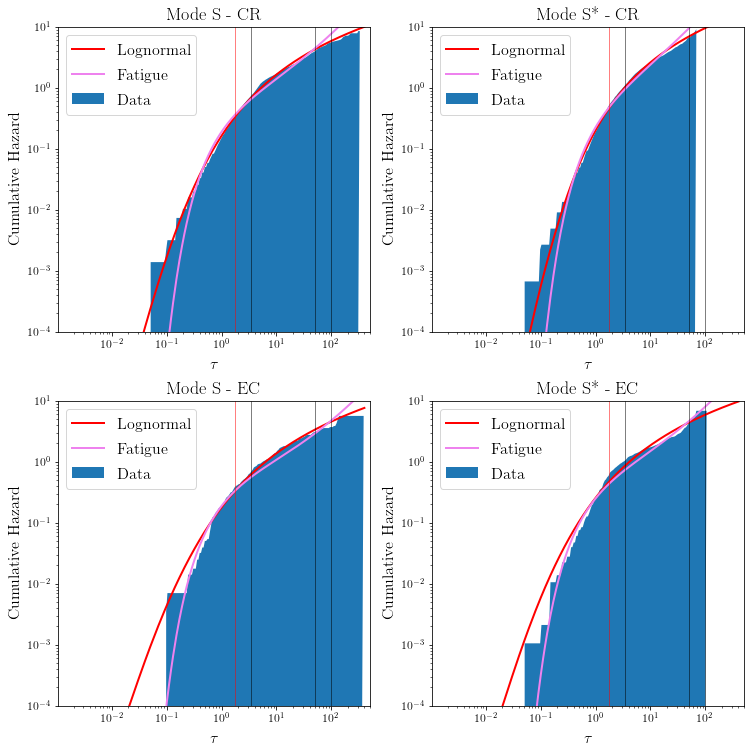

In [69]:
def get_cumulative_hazard(tau1):
    PDF = np.histogram(tau1.values, np.logspace(-3,3,256))
    CDF = np.cumsum(PDF[0])
    CDF = CDF/CDF[-1]
    
    x = 0.5*(PDF[1][1:]+PDF[1][:-1])
    y = -np.log(1-CDF)
    
    return x, y


plt.rcParams['figure.figsize'] = (10.5, 10.5)

f, axes = plt.subplots(2,2, sharex=False, sharey=False)
ax= np.ravel(axes)

x5, y5 = get_cumulative_hazard(zero3_pr3.loc[zero3_pr3.isrev==True].tau)
x6, y6 = get_cumulative_hazard(zero4_pr3.loc[zero4_pr3.isrev==True].tau)
x7, y7 = get_cumulative_hazard(zero3_pr3.loc[zero3_pr3.isrev==False].tau)
x8, y8 = get_cumulative_hazard(zero4_pr3.loc[zero4_pr3.isrev==False].tau)

ax[0].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s3c_cr_pr3/(1-c3c_cr_pr3), x=tau), 'r', linewidth=2.0)
ax[1].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s4c_cr_pr3/(1-c4c_cr_pr3), x=tau), 'r', linewidth=2.0)
ax[2].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s3c_ec_pr3/(1-c3c_ec_pr3), x=tau), 'r', linewidth=2.0)
ax[3].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s4c_ec_pr3/(1-c4c_ec_pr3), x=tau), 'r', linewidth=2.0)

ax[0].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s3d_cr_pr3/(1-c3d_cr_pr3), x=tau), 'violet', linewidth=2.0)
ax[1].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s4d_cr_pr3/(1-c4d_cr_pr3), x=tau), 'violet', linewidth=2.0)
ax[2].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s3d_ec_pr3/(1-c3d_ec_pr3), x=tau), 'violet', linewidth=2.0)
ax[3].plot(0.5*(tau[1:]+tau[1:]), cumtrapz(s4d_ec_pr3/(1-c4d_ec_pr3), x=tau), 'violet', linewidth=2.0)

ax[0].fill(x5, y5)
ax[1].fill(x6, y6)
ax[2].fill(x7, y7)
ax[3].fill(x8, y8)

ax[0].set_title('Mode S - CR', size=18)
ax[1].set_title('Mode S* - CR', size=18)
ax[2].set_title('Mode S - EC', size=18)
ax[3].set_title('Mode S* - EC', size=18)

for i in range(4):
    ax[i].legend(['Lognormal', 'Fatigue', 'Data'])
    
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlabel('$\\tau$')
    ax[i].set_ylabel('Cumulative Hazard')
    ax[i].set_xlim([0,500])
    ax[i].set_ylim([1e-4,1e1])

    ax[i].axvline(x=3.5/2, color='r', linewidth=0.5)
    ax[i].axvline(x=3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=100.0, color='k', linewidth=0.5)
    
    
plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_c6.pdf',dpi=300)

In [70]:
from findiff.coefs import coefficients
from findiff.operators import FinDiff, Coef, Identity, Coefficient
from findiff.vector import Gradient, Divergence, Curl, Laplacian

d_dx = FinDiff(0, x1, acc=4)
dy1_dx = d_dx(y1)
dy2_dx = d_dx(y2)
dy3_dx = d_dx(y3)
dy4_dx = d_dx(y4)
dy5_dx = d_dx(y5)
dy6_dx = d_dx(y6)
dy7_dx = d_dx(y7)
dy8_dx = d_dx(y8)

/people/castillo/coreCloud/HouseCleaning_AC/01_reversals/findiff/operators.py:270: RuntimeWarning: invalid value encountered in add
  yd[ref_multi_slice] += w * y[multi_slice]


/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:25: RuntimeWarning: divide by zero encountered in true_divide


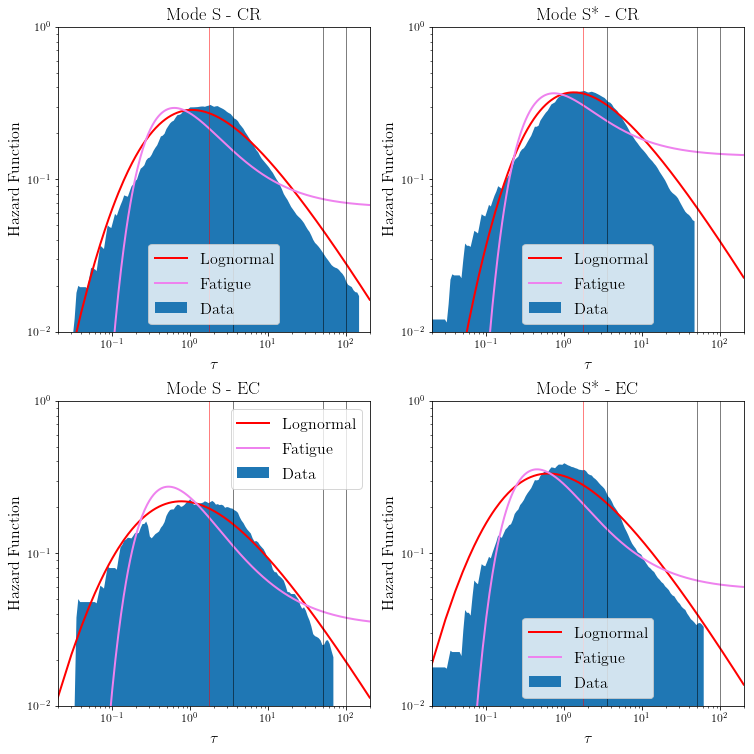

In [71]:
plt.rcParams['figure.figsize'] = (10.5, 10.5)

f, axes = plt.subplots(2,2, sharex=False, sharey=False)
ax= np.ravel(axes)


#ax[0].plot(x1, dy1_dx)
#ax[1].plot(x2, dy2_dx)
#ax[2].plot(x3, dy3_dx)
#ax[3].plot(x4, dy4_dx)

N=40
ax[0].fill(x1[int(N/2):-int(N/2)+1], np.convolve(dy1_dx, np.ones((N,))/N, mode='valid'))
ax[1].fill(x1[int(N/2):-int(N/2)+1], np.convolve(dy2_dx, np.ones((N,))/N, mode='valid'))
ax[2].fill(x1[int(N/2):-int(N/2)+1], np.convolve(dy3_dx, np.ones((N,))/N, mode='valid'))
ax[3].fill(x1[int(N/2):-int(N/2)+1], np.convolve(dy4_dx, np.ones((N,))/N, mode='valid'))


ax[0].plot(tau, s3c_cr_pr43/(1-c3c_cr_pr43), 'r', linewidth=2.0)
ax[1].plot(tau, s4c_cr_pr43/(1-c4c_cr_pr43), 'r', linewidth=2.0)
ax[2].plot(tau, s3c_ec_pr43/(1-c3c_ec_pr43), 'r', linewidth=2.0)
ax[3].plot(tau, s4c_ec_pr43/(1-c4c_ec_pr43), 'r', linewidth=2.0)

ax[0].plot(tau, s3d_cr_pr43/(1-c3d_cr_pr43), 'violet', linewidth=2.0)
ax[1].plot(tau, s4d_cr_pr43/(1-c4d_cr_pr43), 'violet', linewidth=2.0)
ax[2].plot(tau, s3d_ec_pr43/(1-c3d_ec_pr43), 'violet', linewidth=2.0)
ax[3].plot(tau, s4d_ec_pr43/(1-c4d_ec_pr43), 'violet', linewidth=2.0)


ax[0].set_title('Mode S - CR', size=18)
ax[1].set_title('Mode S* - CR', size=18)
ax[2].set_title('Mode S - EC', size=18)
ax[3].set_title('Mode S* - EC', size=18)

for i in range(4):
    ax[i].legend(['Lognormal', 'Fatigue', 'Data'])
    
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    
    ax[i].set_ylim([1e-2,1e0])
    ax[i].set_xlim([0.02,200])
    
    ax[i].set_xlabel('$\\tau$')
    ax[i].set_ylabel('Hazard Function')
    
    ax[i].axvline(x=3.5/2, color='r', linewidth=0.5)
    ax[i].axvline(x=3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=100.0, color='k', linewidth=0.5)    
    
plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_c7.pdf',dpi=300)

/people/castillo/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:25: RuntimeWarning: divide by zero encountered in true_divide


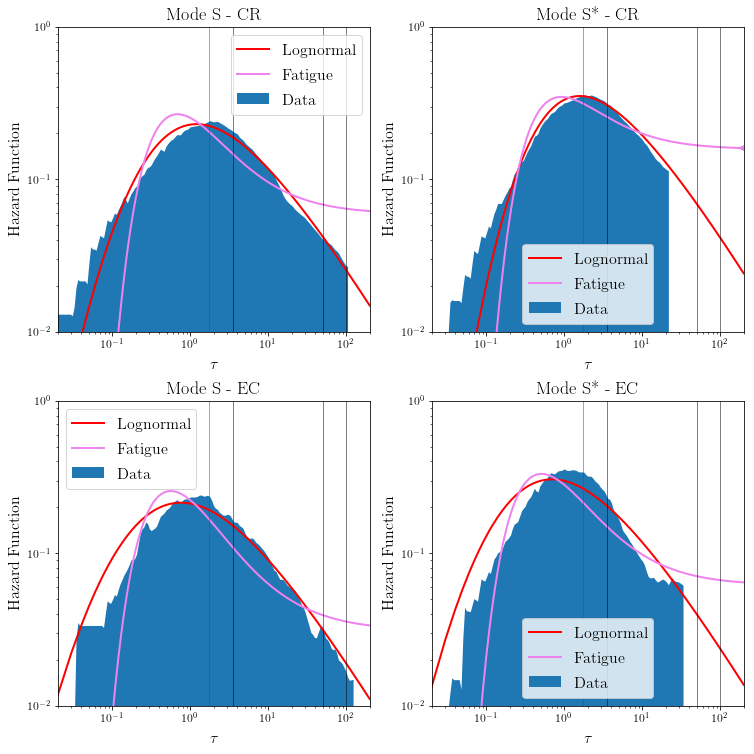

In [72]:
plt.rcParams['figure.figsize'] = (10.5, 10.5)

f, axes = plt.subplots(2,2, sharex=False, sharey=False)
ax= np.ravel(axes)


#ax[0].plot(x5, dy5_dx)
#ax[1].plot(x6, dy6_dx)
#ax[2].plot(x7, dy7_dx)
#ax[3].plot(x8, dy8_dx)

N=40
ax[0].fill(x1[int(N/2):-int(N/2)+1], np.convolve(dy5_dx, np.ones((N,))/N, mode='valid'))
ax[1].fill(x1[int(N/2):-int(N/2)+1], np.convolve(dy6_dx, np.ones((N,))/N, mode='valid'))
ax[2].fill(x1[int(N/2):-int(N/2)+1], np.convolve(dy7_dx, np.ones((N,))/N, mode='valid'))
ax[3].fill(x1[int(N/2):-int(N/2)+1], np.convolve(dy8_dx, np.ones((N,))/N, mode='valid'))


ax[0].plot(tau, s3c_cr_pr3/(1-c3c_cr_pr3), 'r', linewidth=2.0)
ax[1].plot(tau, s4c_cr_pr3/(1-c4c_cr_pr3), 'r', linewidth=2.0)
ax[2].plot(tau, s3c_ec_pr3/(1-c3c_ec_pr3), 'r', linewidth=2.0)
ax[3].plot(tau, s4c_ec_pr3/(1-c4c_ec_pr3), 'r', linewidth=2.0)

ax[0].plot(tau, s3d_cr_pr3/(1-c3d_cr_pr3), 'violet', linewidth=2.0)
ax[1].plot(tau, s4d_cr_pr3/(1-c4d_cr_pr3), 'violet', linewidth=2.0)
ax[2].plot(tau, s3d_ec_pr3/(1-c3d_ec_pr3), 'violet', linewidth=2.0)
ax[3].plot(tau, s4d_ec_pr3/(1-c4d_ec_pr3), 'violet', linewidth=2.0)


ax[0].set_title('Mode S - CR', size=18)
ax[1].set_title('Mode S* - CR', size=18)
ax[2].set_title('Mode S - EC', size=18)
ax[3].set_title('Mode S* - EC', size=18)

for i in range(4):
    ax[i].legend(['Lognormal', 'Fatigue', 'Data'])
    
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    
    ax[i].set_ylim([1e-2,1e0])
    ax[i].set_xlim([0.02,200])

    
    ax[i].set_xlabel('$\\tau$')
    ax[i].set_ylabel('Hazard Function')
    
    ax[i].axvline(x=3.5/2, color='r', linewidth=0.5)
    ax[i].axvline(x=3.5, color='k', linewidth=0.5)
    ax[i].axvline(x=50.0, color='k', linewidth=0.5)
    ax[i].axvline(x=100.0, color='k', linewidth=0.5)    
    
plt.tight_layout(pad=0.5) 
plt.savefig('appendices/appendix_c8.pdf',dpi=300)